# Experiment 1 — vertical heat-transport skill (symmetric regular-shape sweep)

experiment_1 counterpart of `experiment_2/heat_flux_summary.ipynb`, restricted to the
symmetric REGULAR-shape families (`symhex`/`symdia`/`symsq`) and using experiment_1's w
method (no surface extrapolation, w=0 at 8 m, 8–70 m sampled column). Built from the
component/flux series in `data_heat/` written by `run_heat_flux.py` +
`run_glider_heat_flux.py`. `[·]` = footprint spatial average, `⟨·⟩` = time average.
Figures → `heat_flux_figs/sym_sweep/`.

In [1]:
import os, sys
import matplotlib.pyplot as plt

REPO = "/home/edavenport/analysis/tpose24-osse"
HERE = os.path.join(REPO, "experiments", "experiment_1")
sys.path.insert(0, REPO)
import heat_flux_fig_tools as hft

# heavy .nc caches live on /data (not /home); see project_sym_disk_truth memory
DATA = os.path.join("/data/SO3/edavenport/tpose24-osse/cache", "experiment_1", "data_heat")
HFIGDIR = os.path.join(HERE, "heat_flux_figs"); os.makedirs(HFIGDIR, exist_ok=True)
plt.rcParams["figure.dpi"] = 120
hft.apply_style()

## Symmetric regular-shape sweep — hexagon / diamond / square

The **symmetric REGULAR shapes** (geometrically regular, isotropic footprints, **no
moorings**) — hexagon (`symhex`), diamond (`symdia`) and square (`symsq`) — at E-W
diameters 0.3 / 0.5 / 0.75 / 1.0° and centres 0.0 / ±0.5°N. Same builders as
experiment_2, under exp1's w method. All figures → `heat_flux_figs/sym_sweep/`.

Per shape family (colour = **centre latitude**): `error_scaling_<fam>.png` (area-average
heating error vs diameter, total = estimate + sub-array), `area_components_<fam>{,_flux}.png`
(structural decomposition, columns = diameter), `area_reducible_<fam>{,_d0.5}.png` and
`point_flux_<fam>.png` (plane-fit ⟨[w]⟩ / ⟨[∂T/∂z]⟩ errors and the area-mean-w stand-in
error). **Shape comparison** `shape_compare_error_scaling_c<lat>.png` (one line per shape).

/home/edavenport/analysis/tpose24-osse/heat_flux_fig_tools.py:870: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axes = plt.subplots(len(rows), 3, figsize=(15, 4.6 * len(rows)),


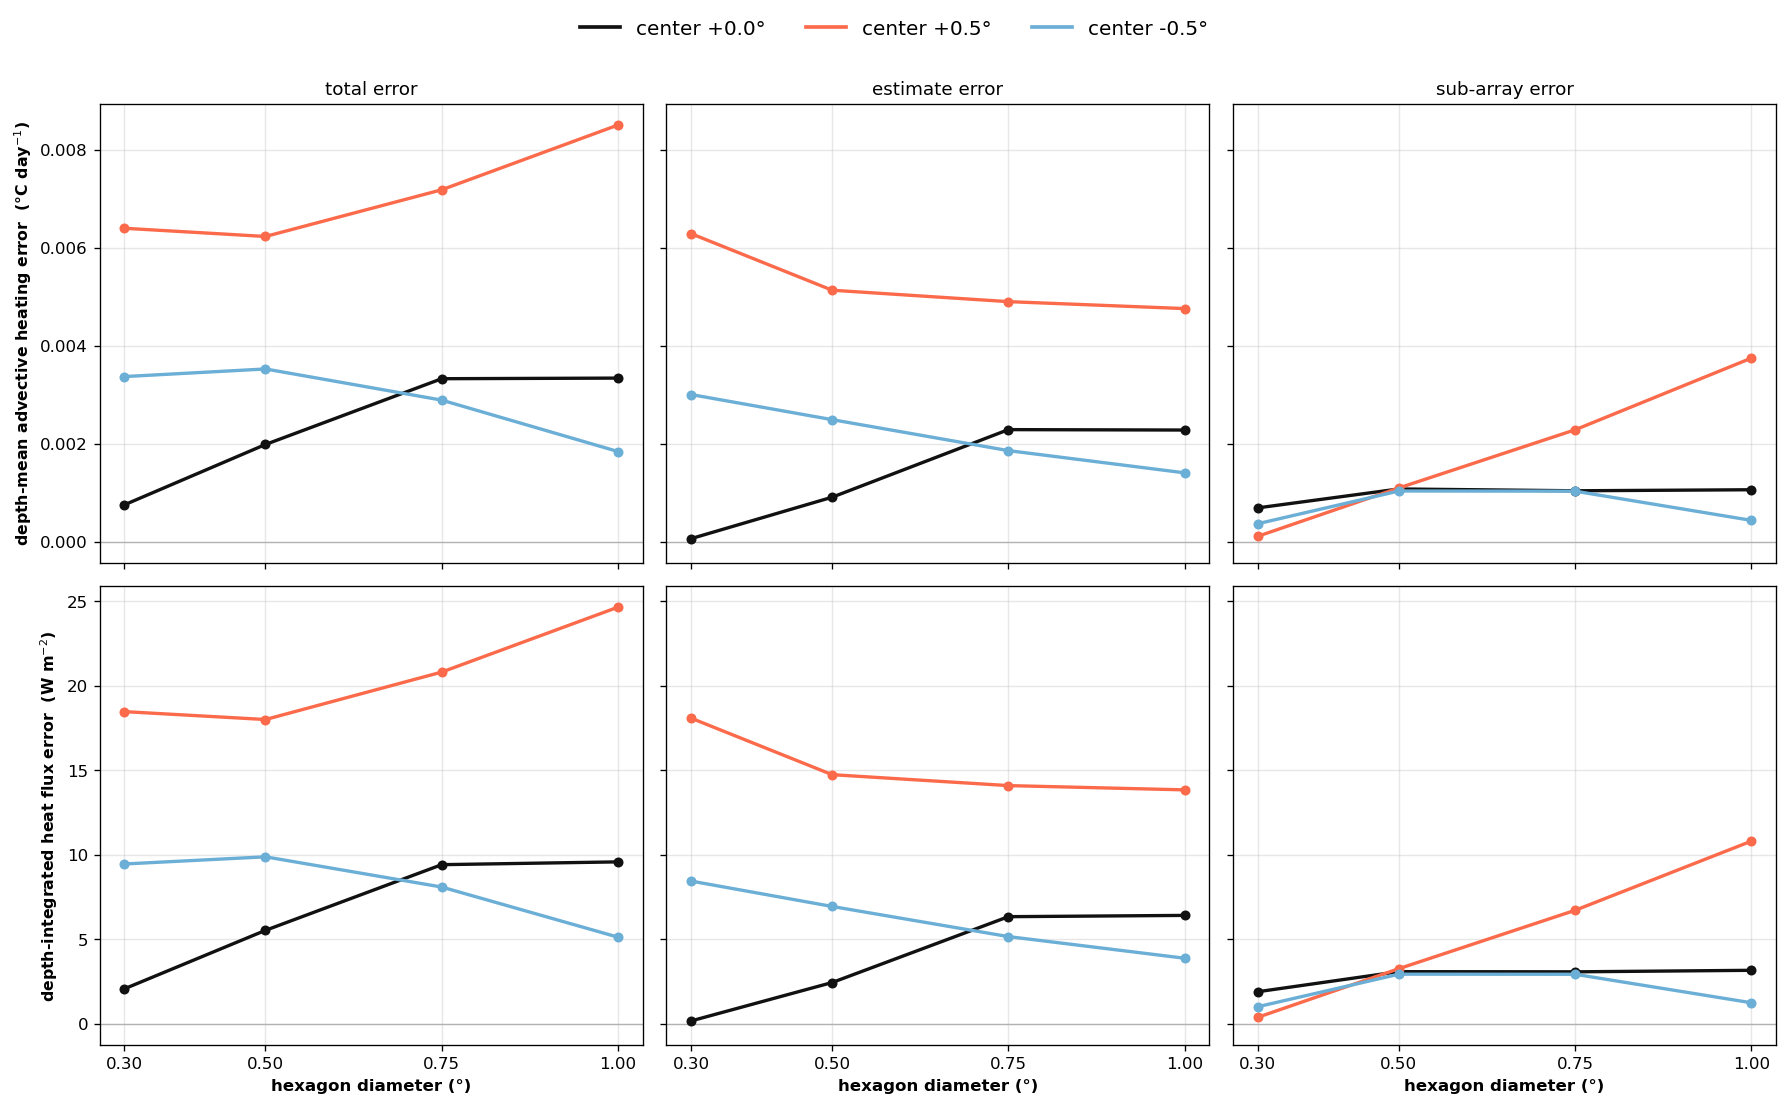

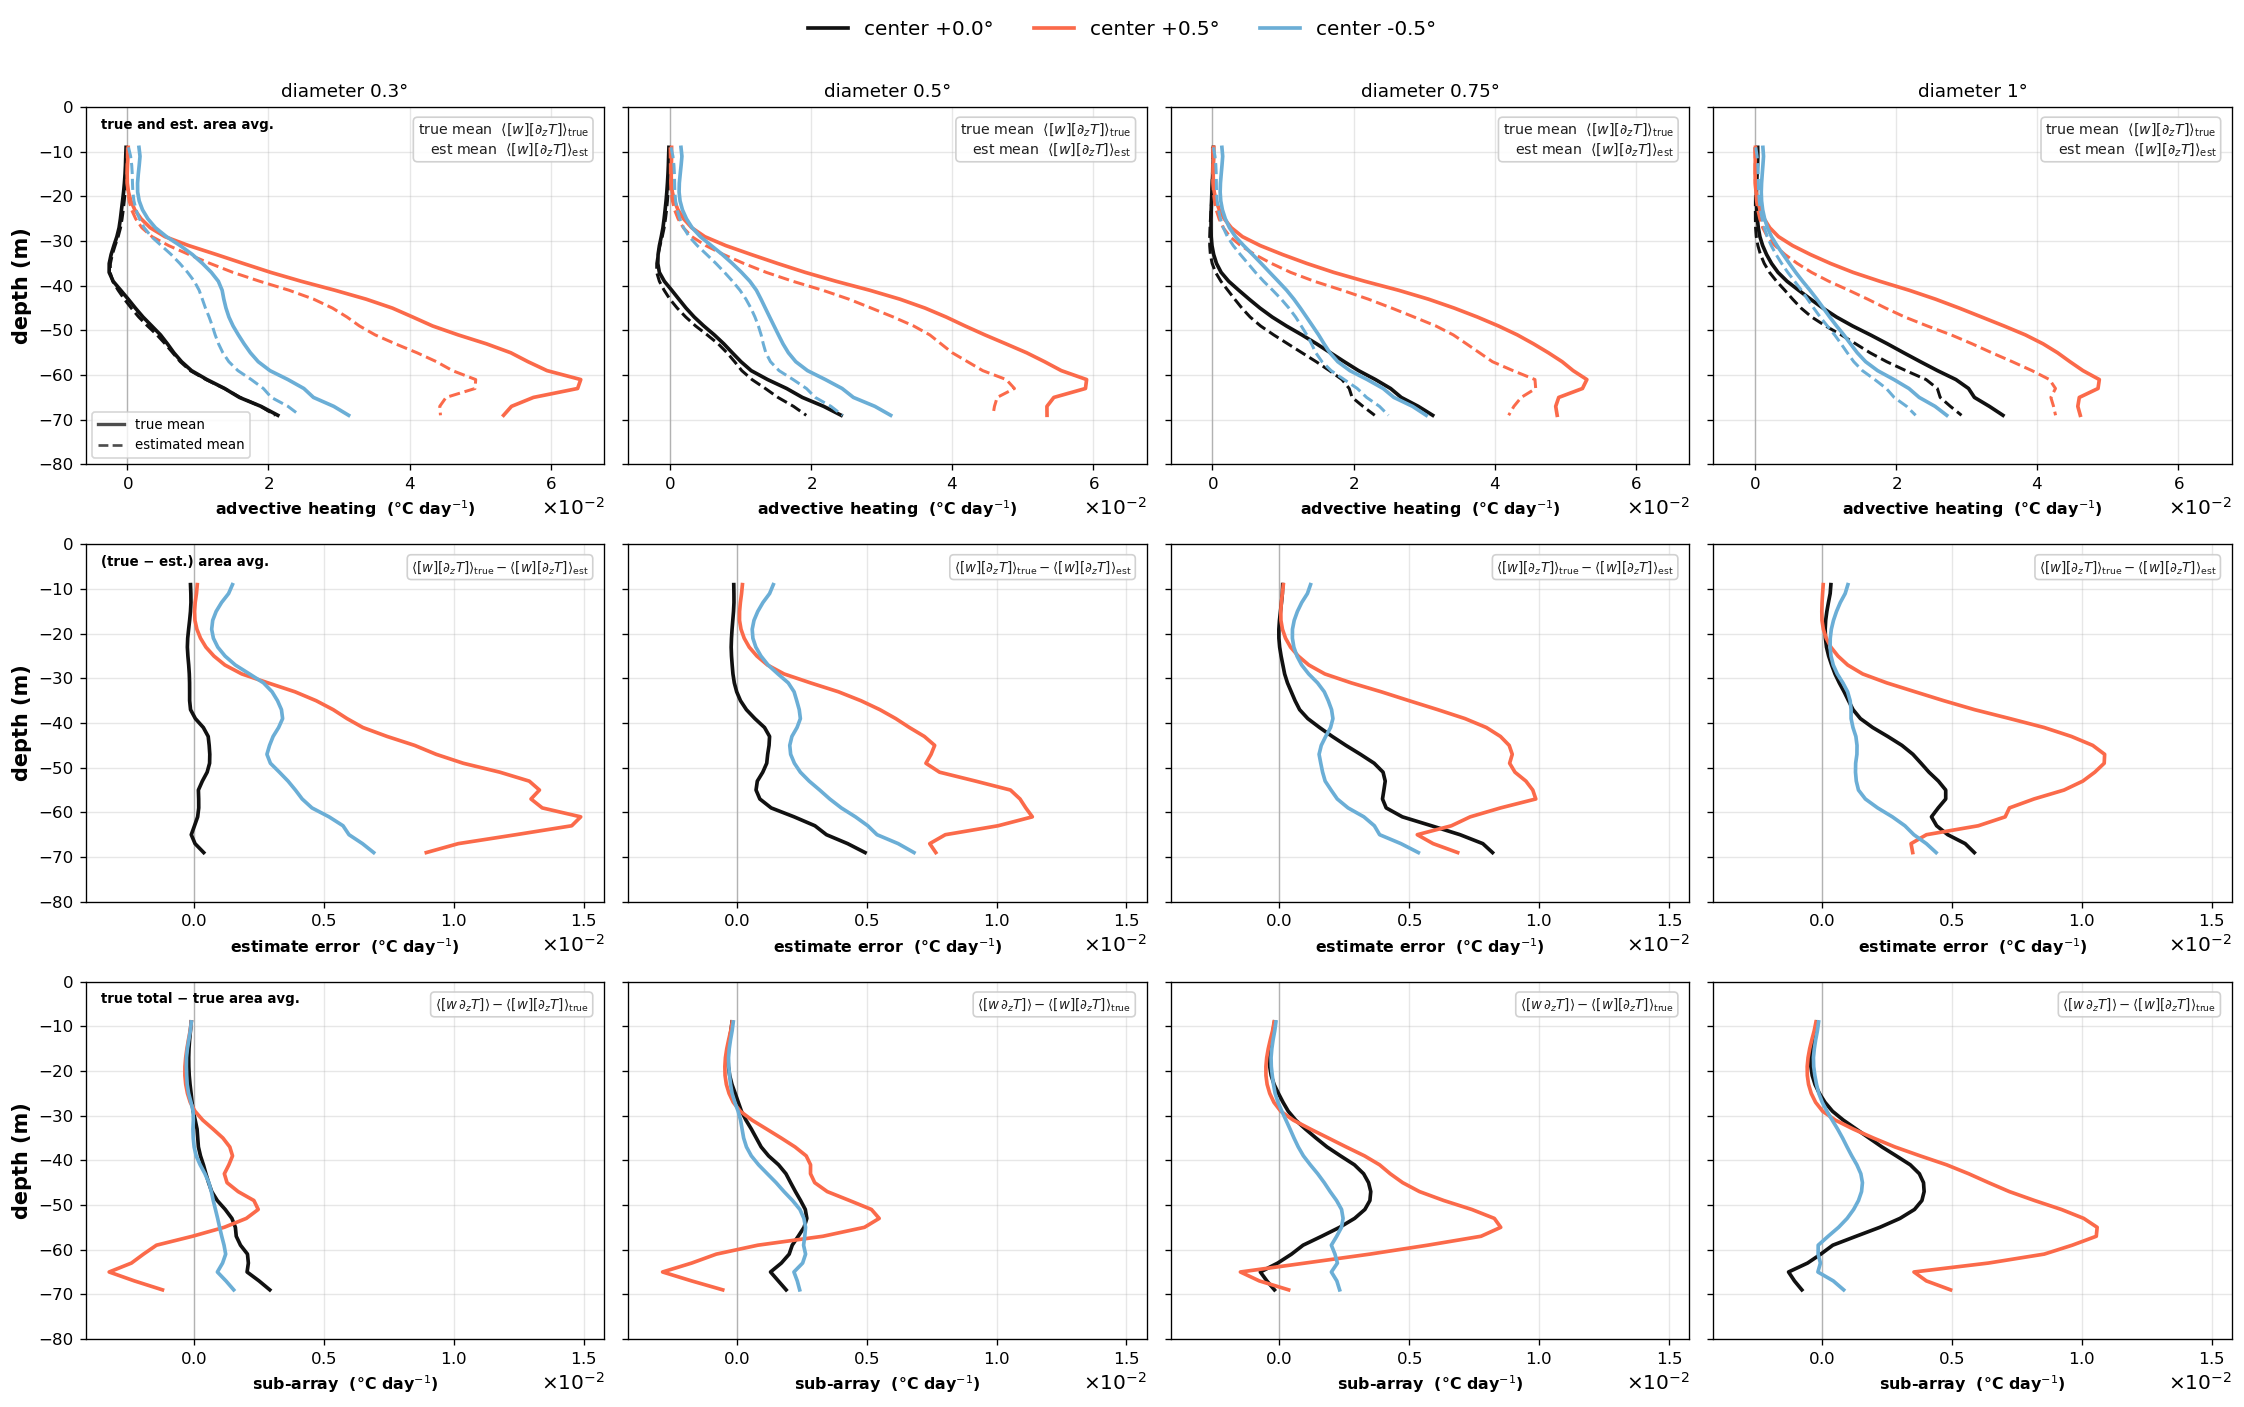

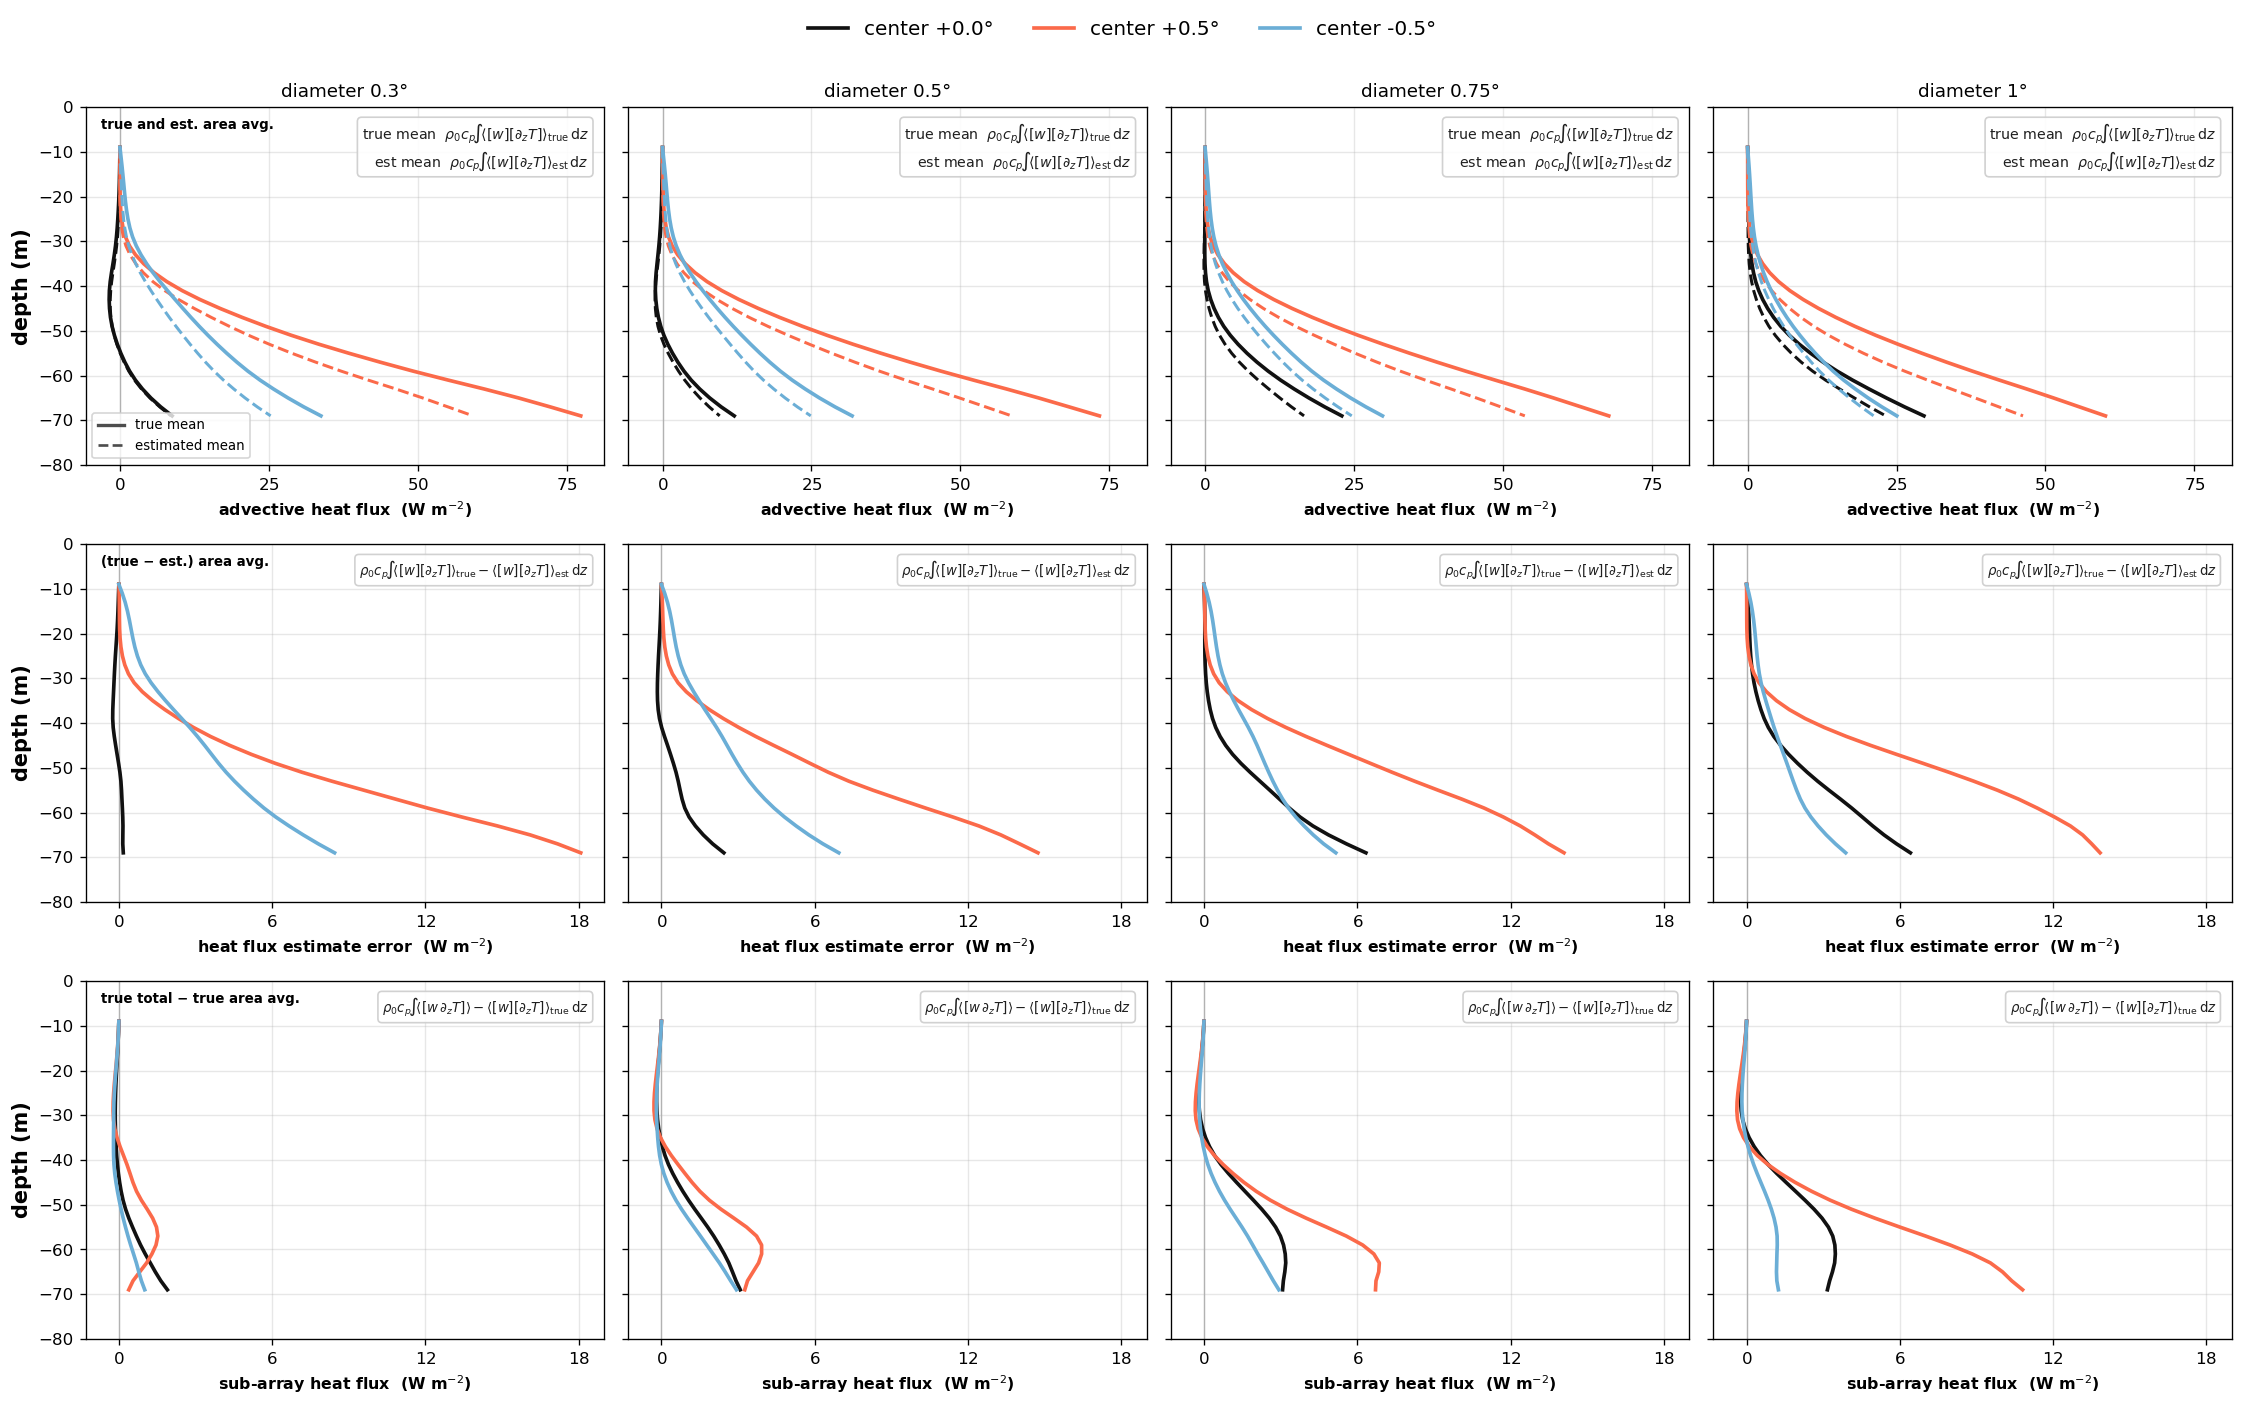

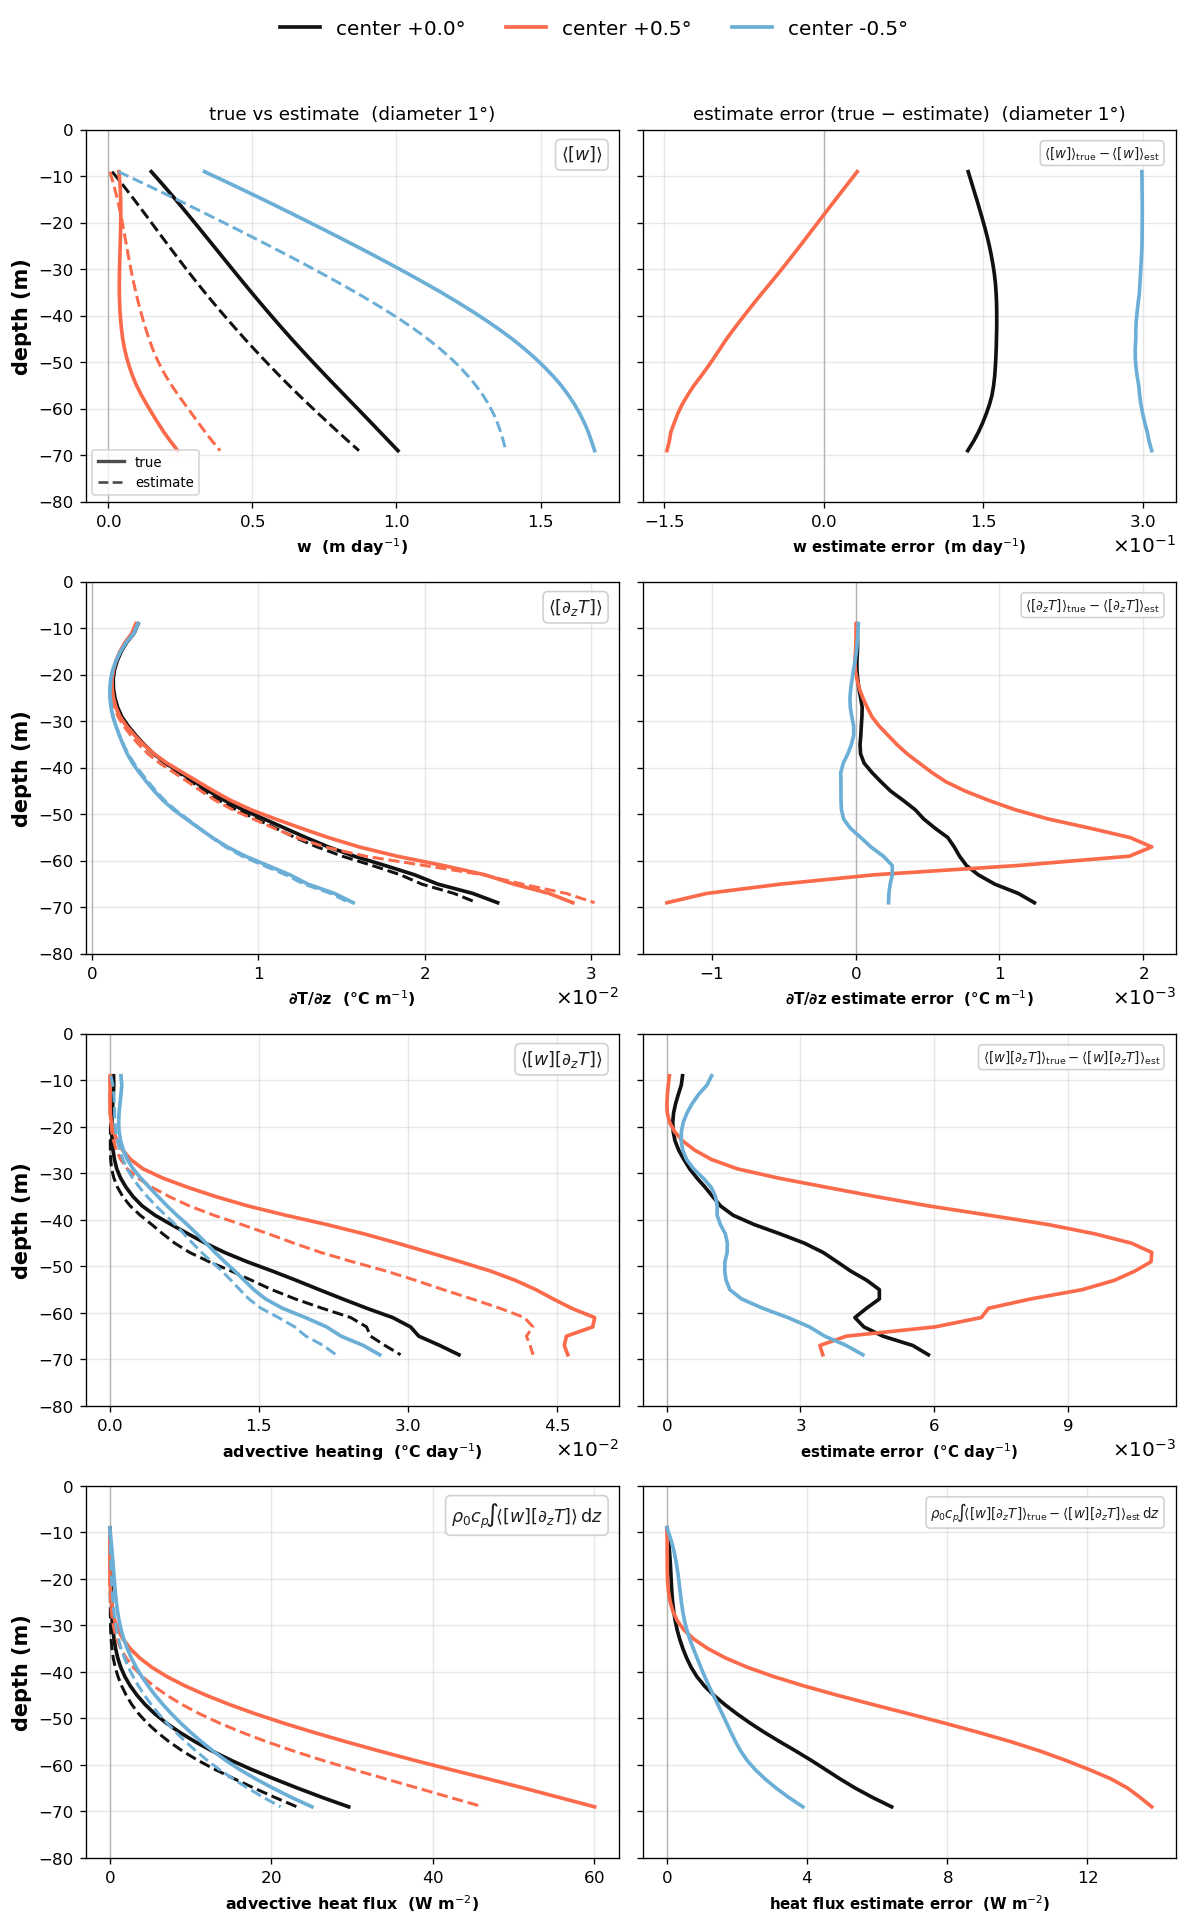

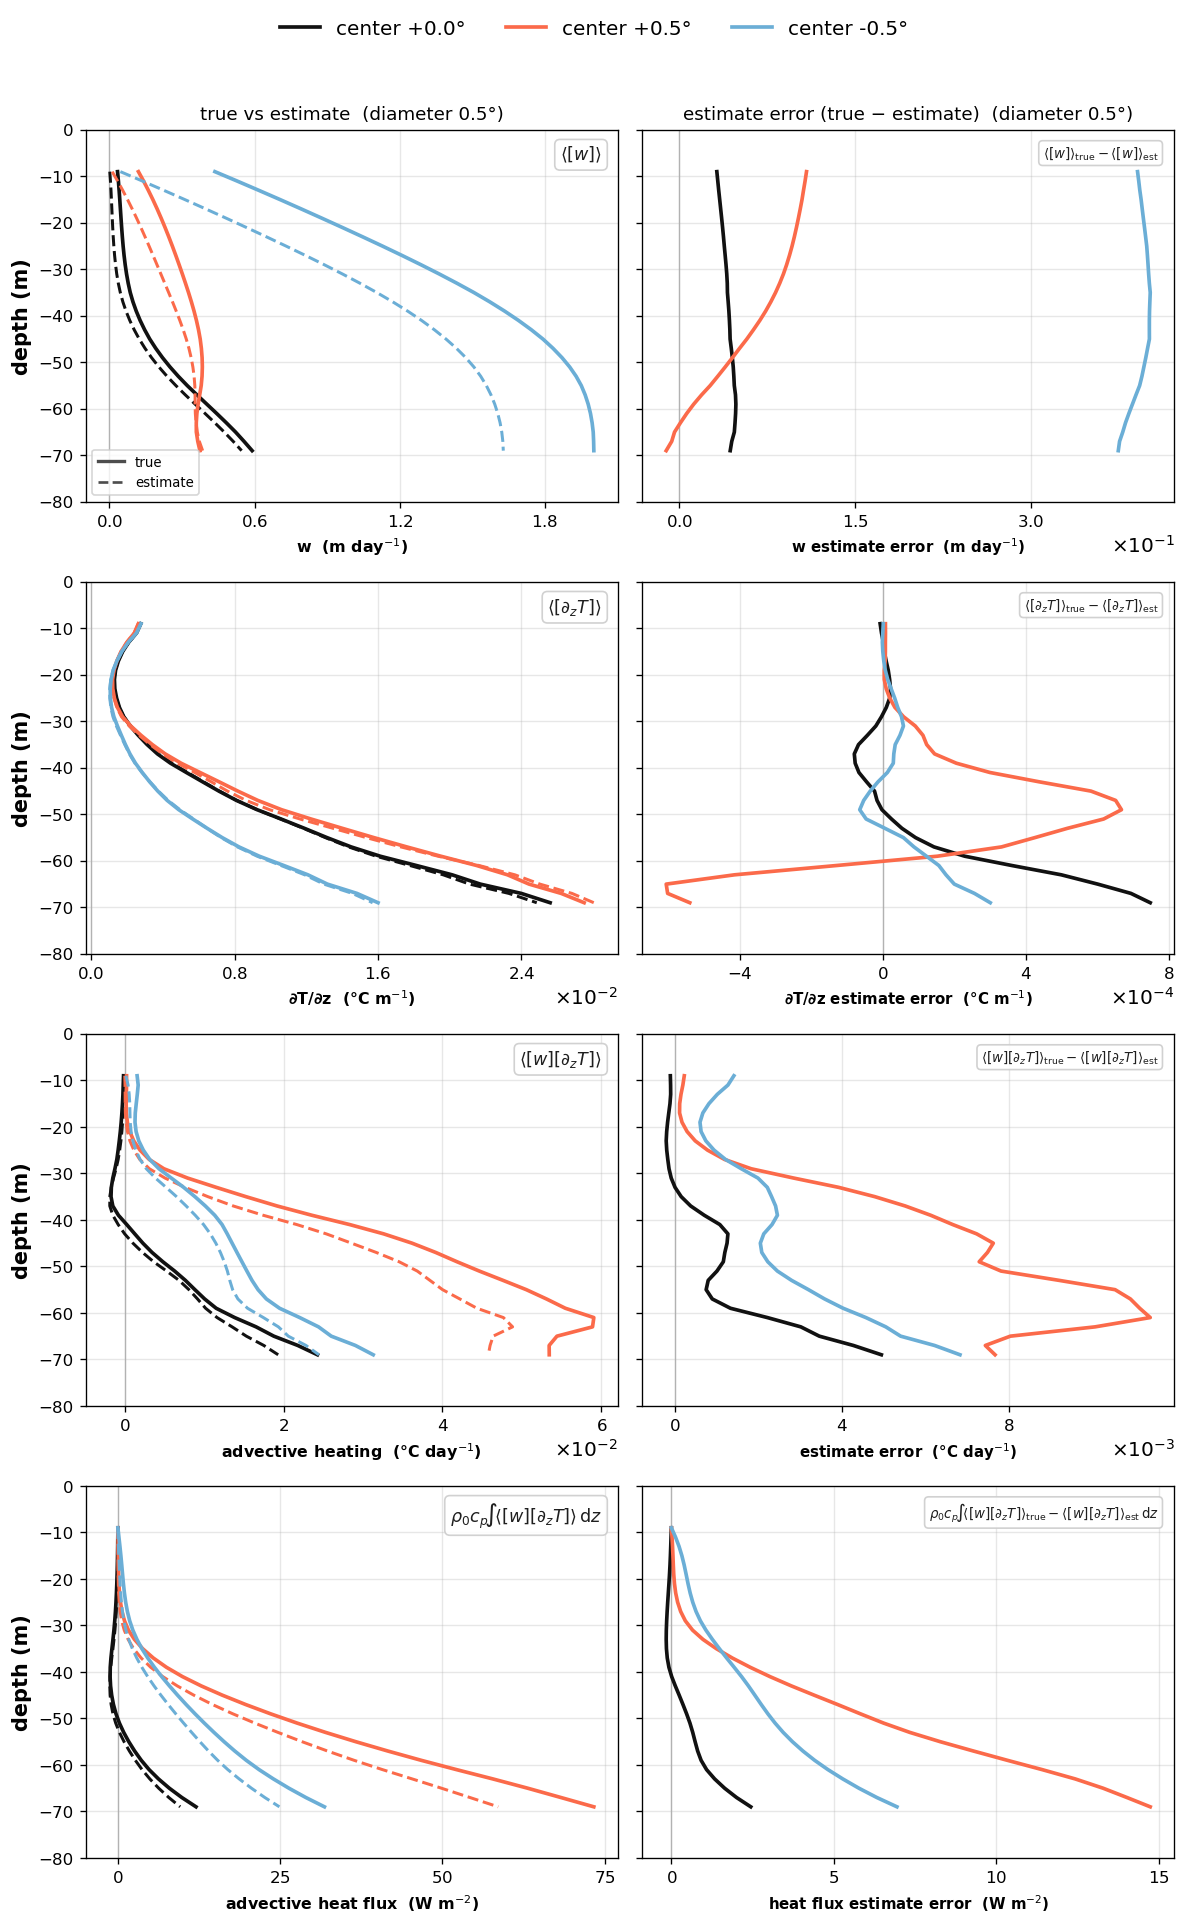

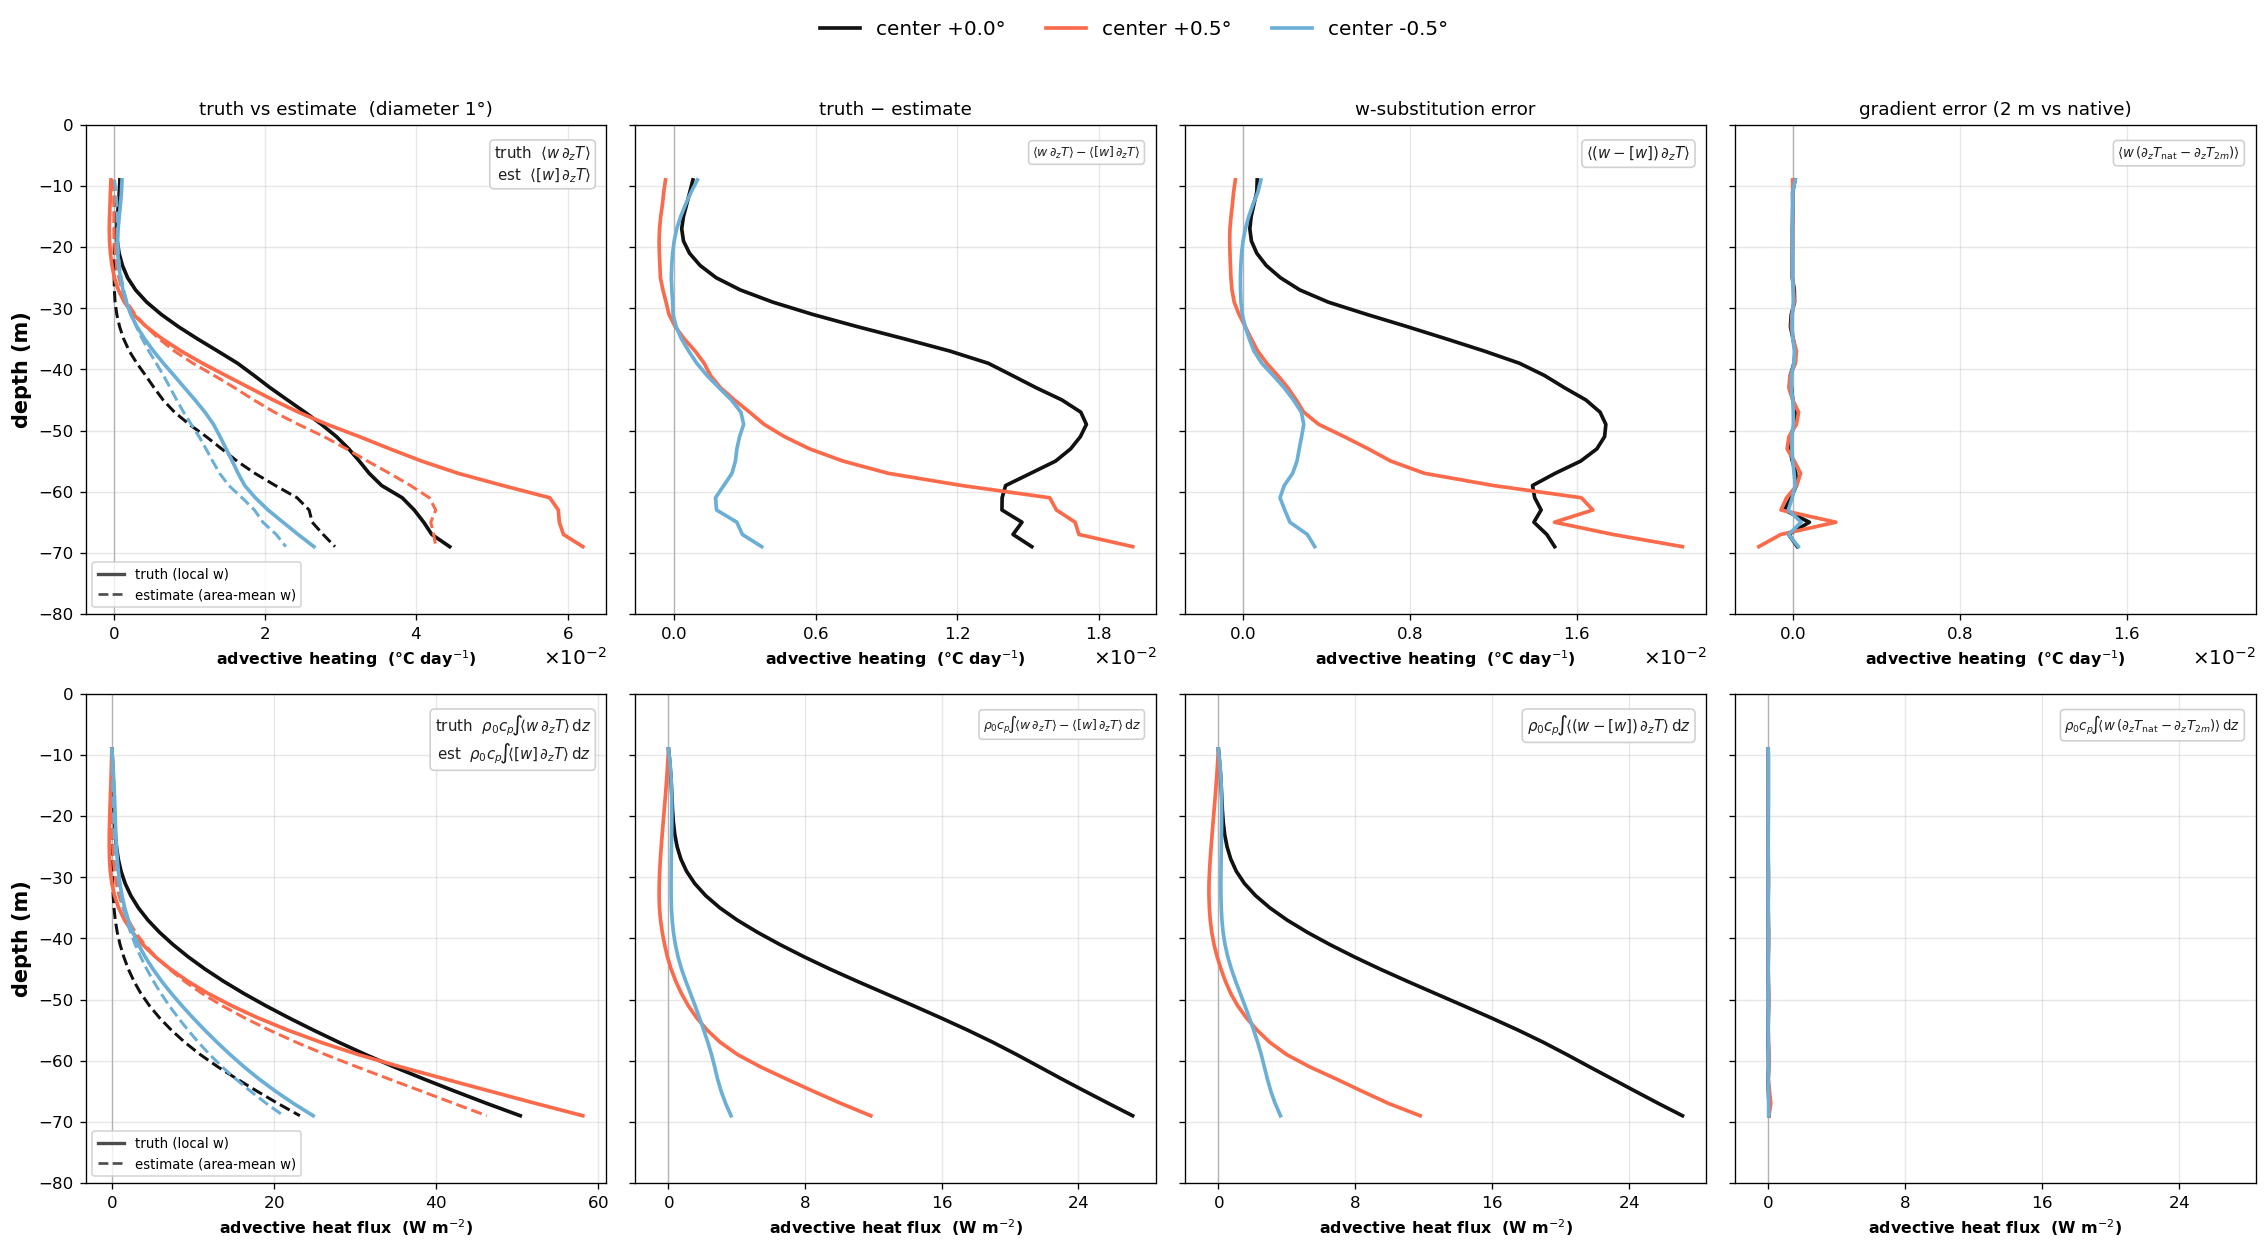

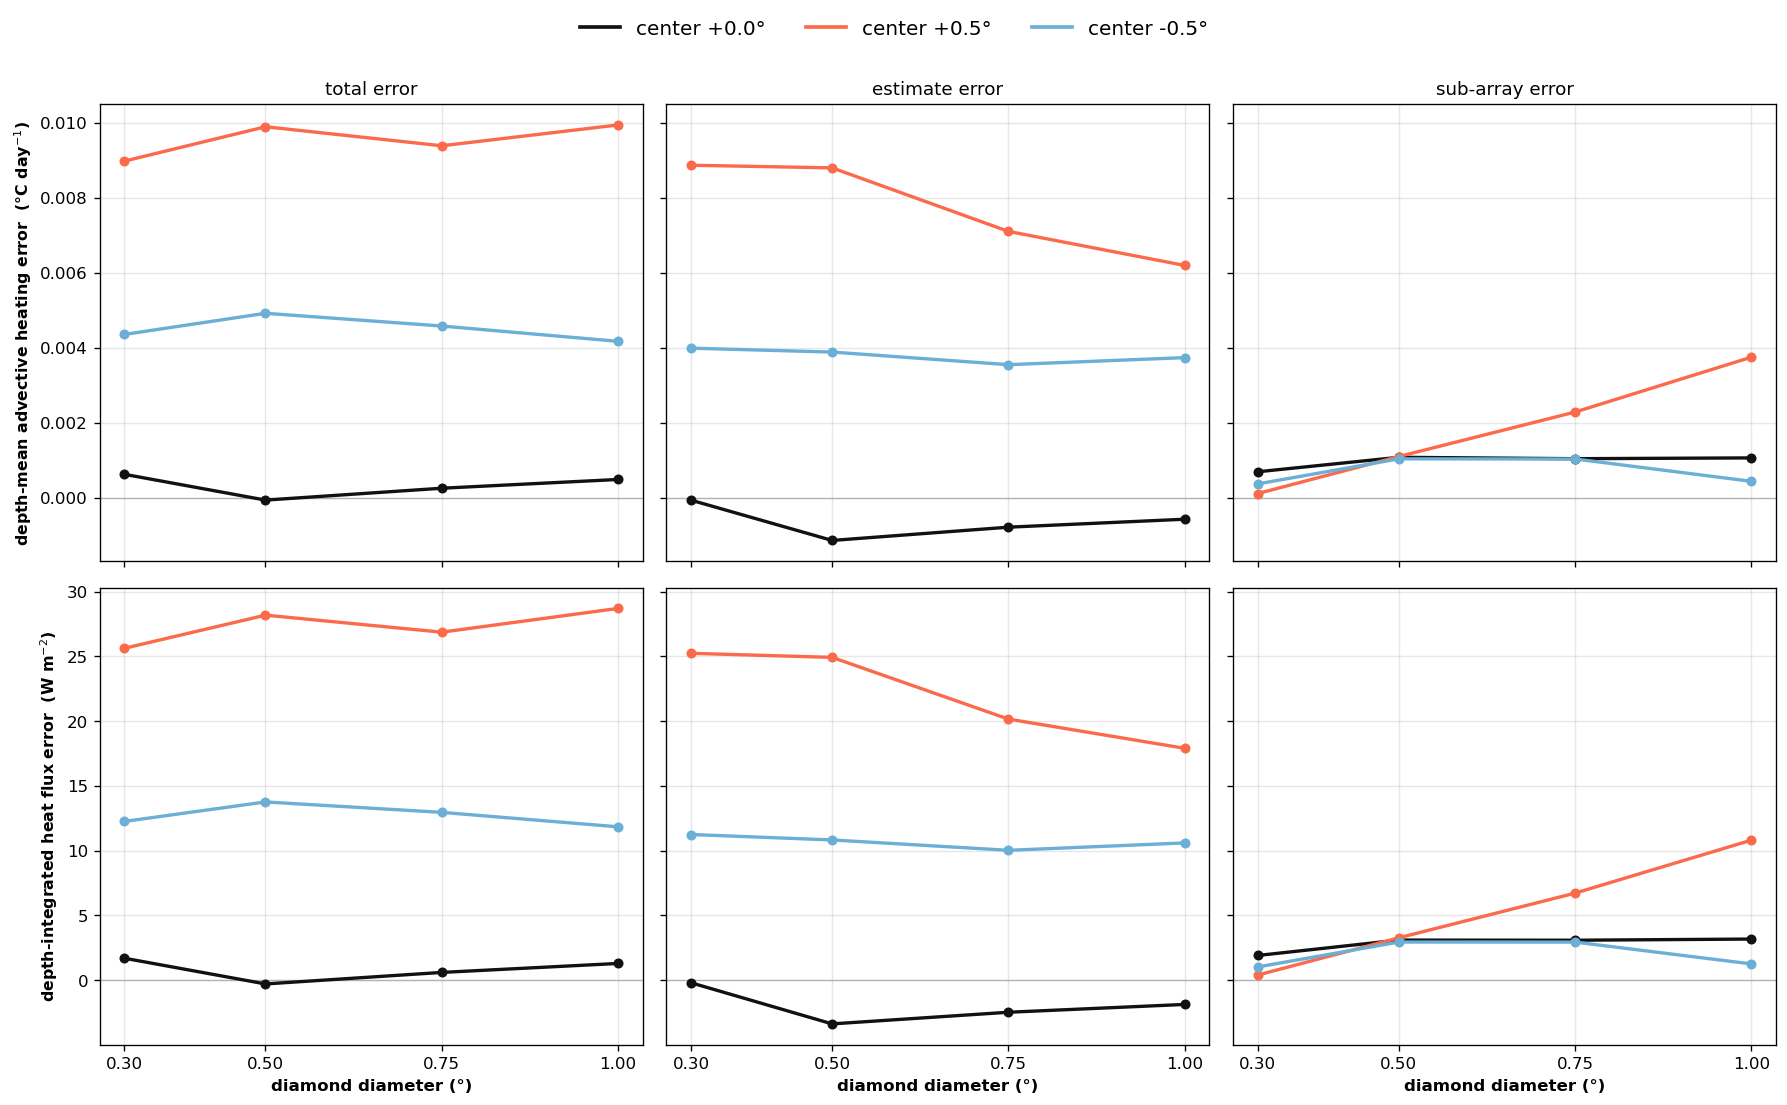

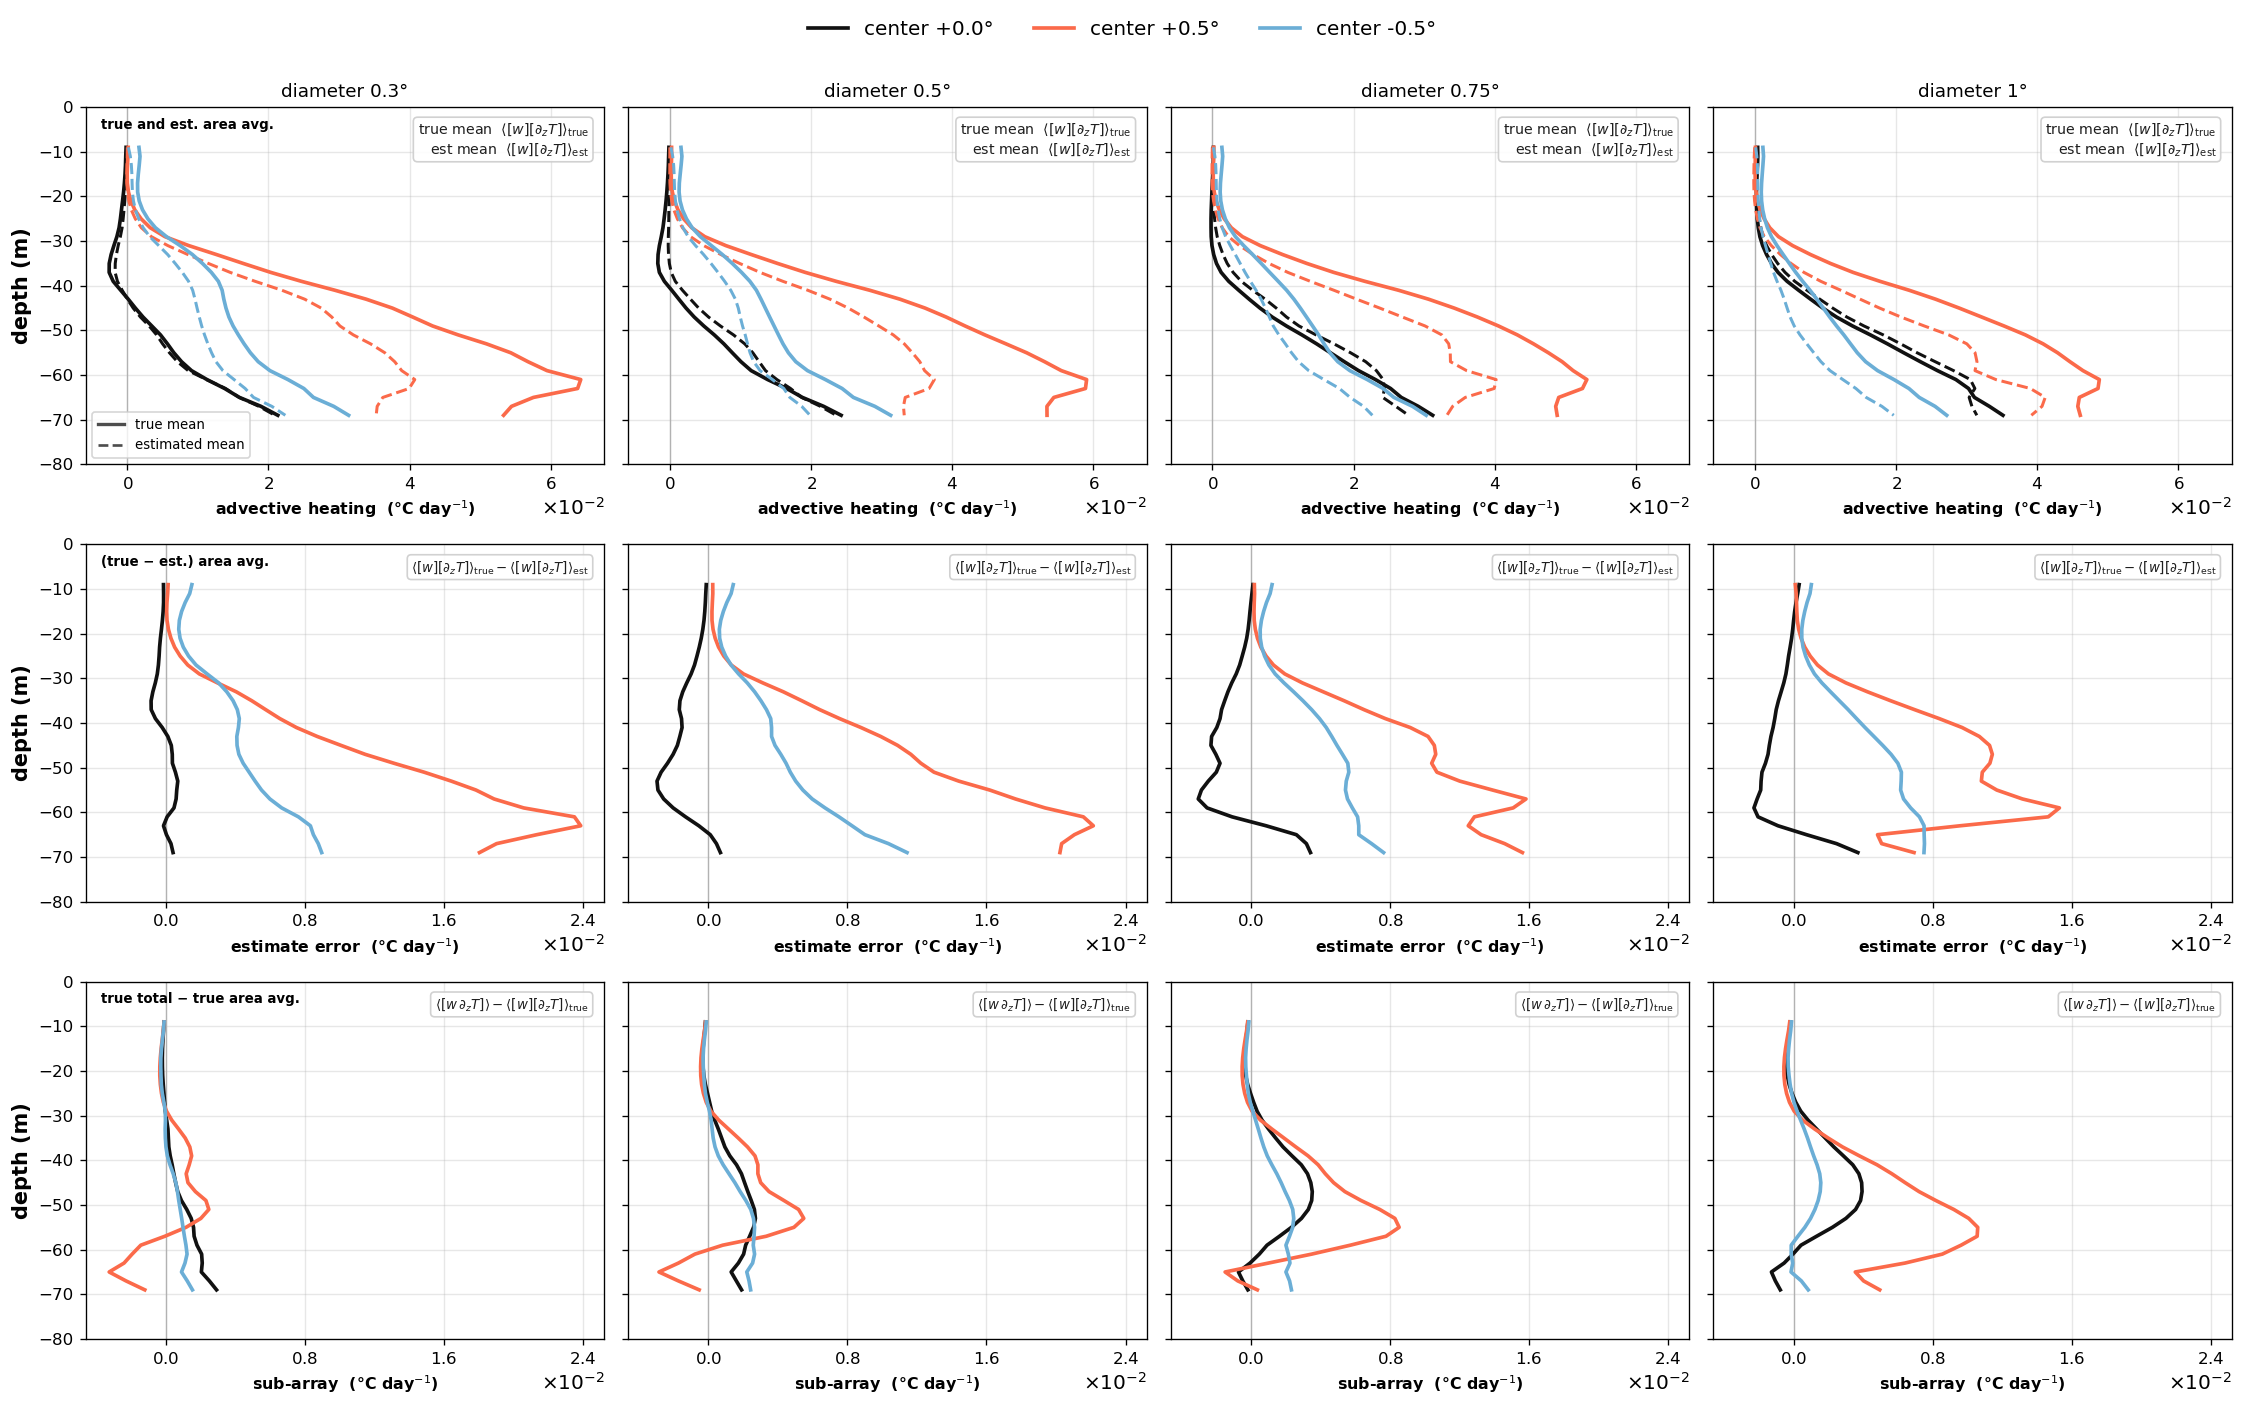

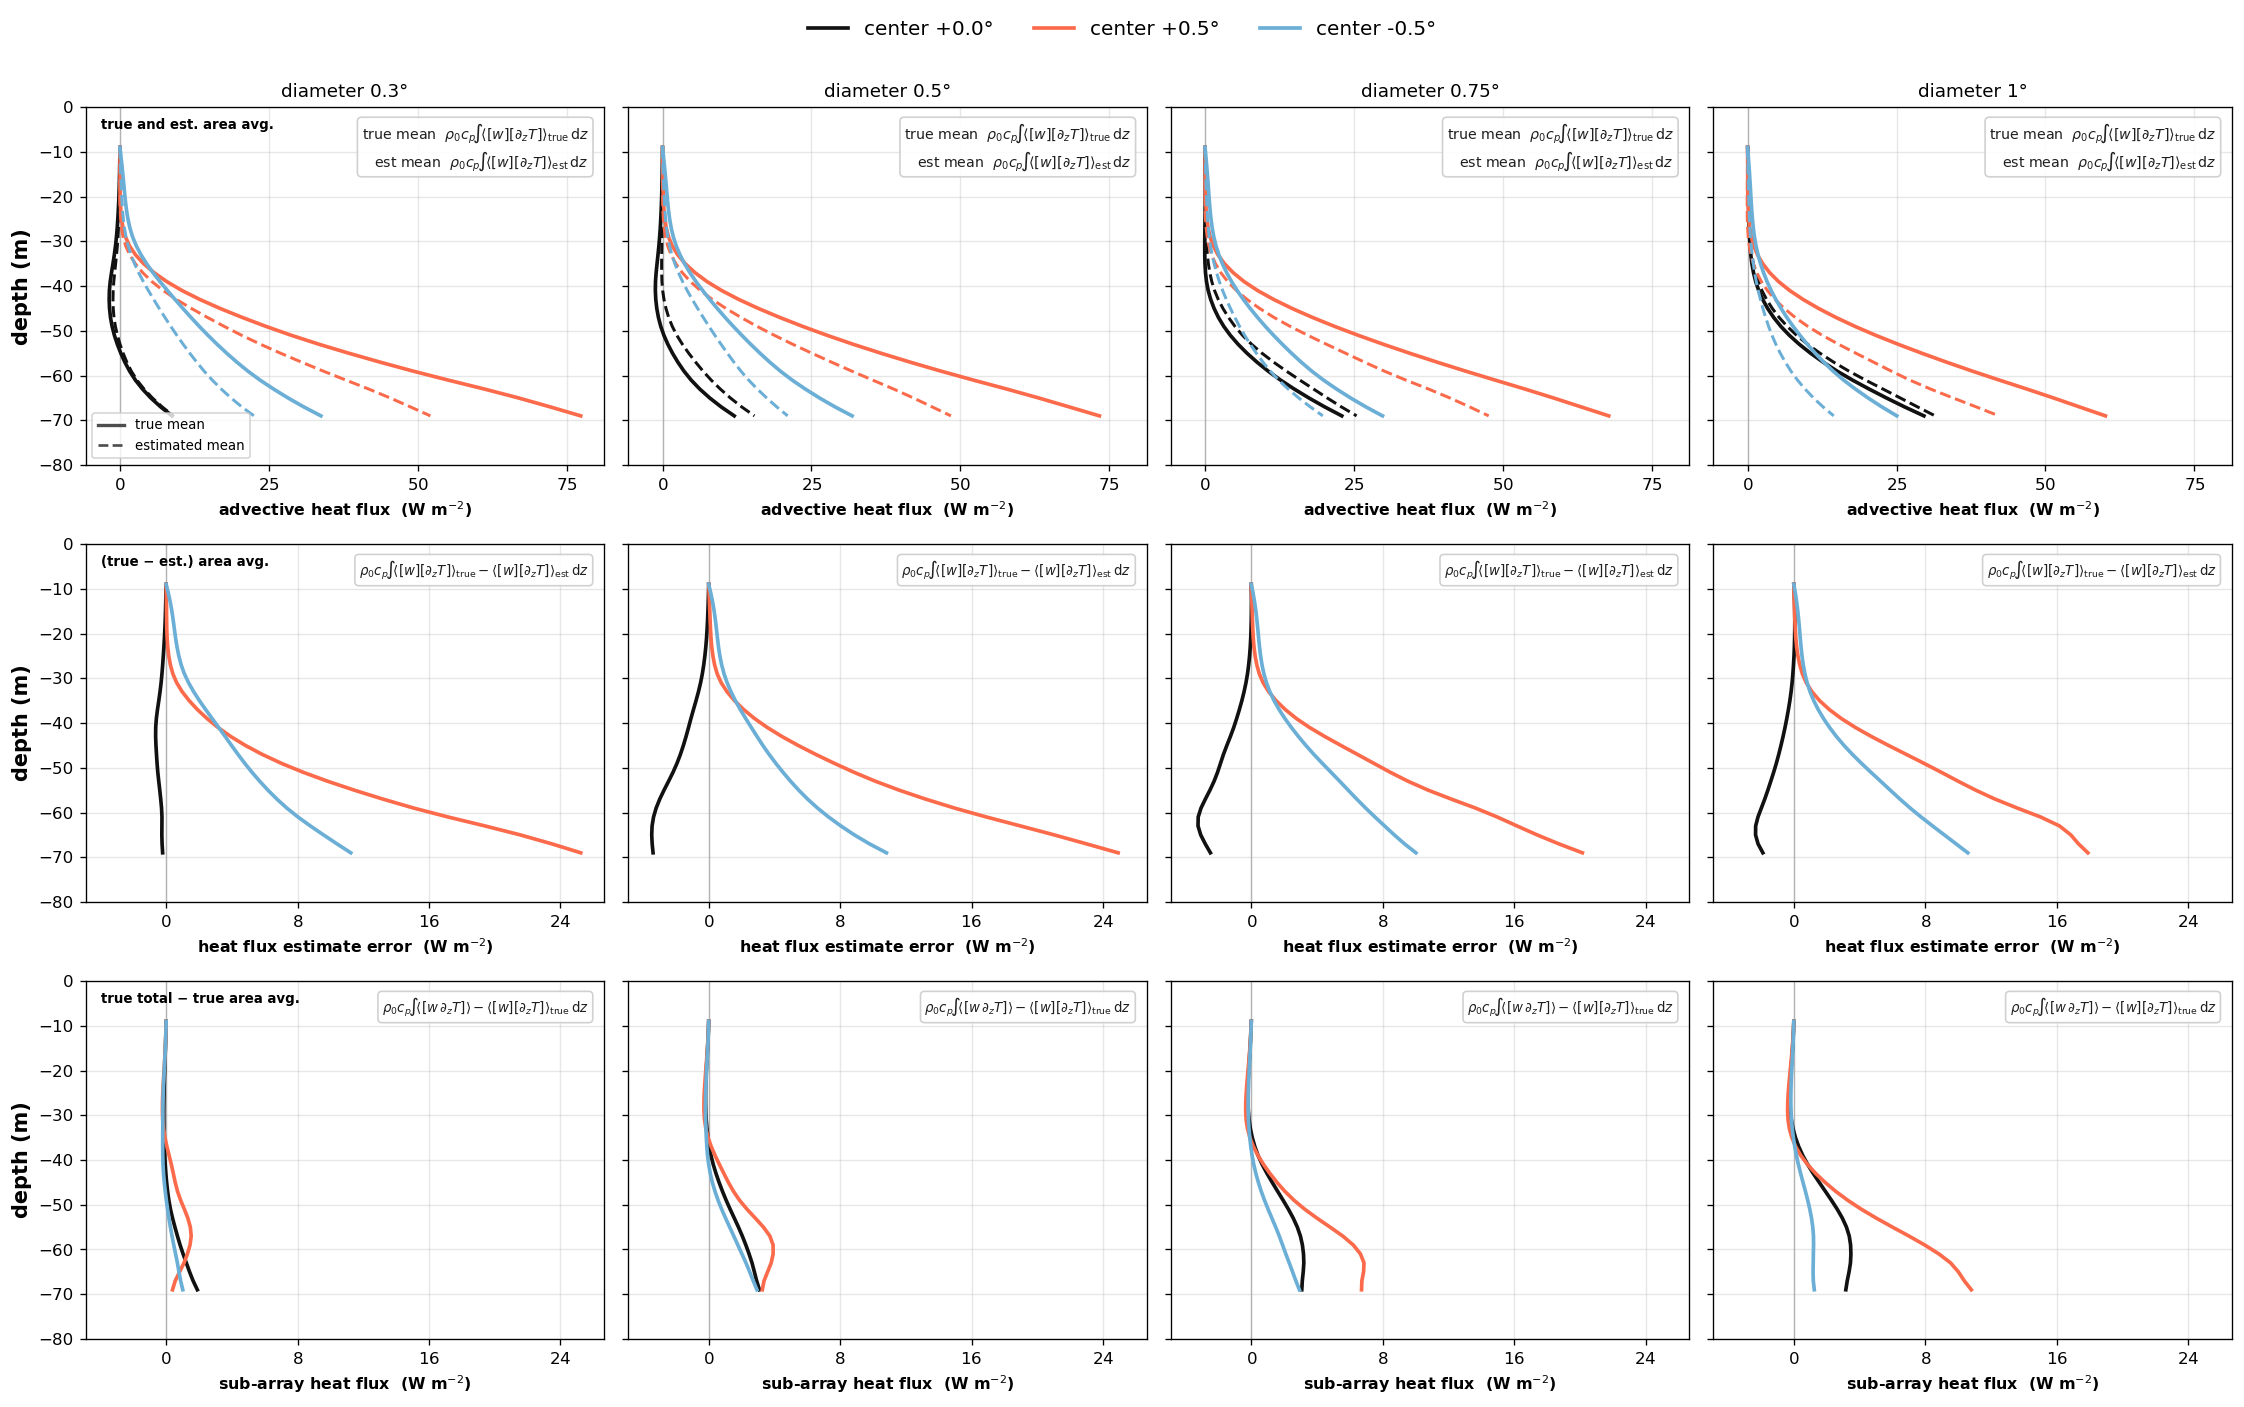

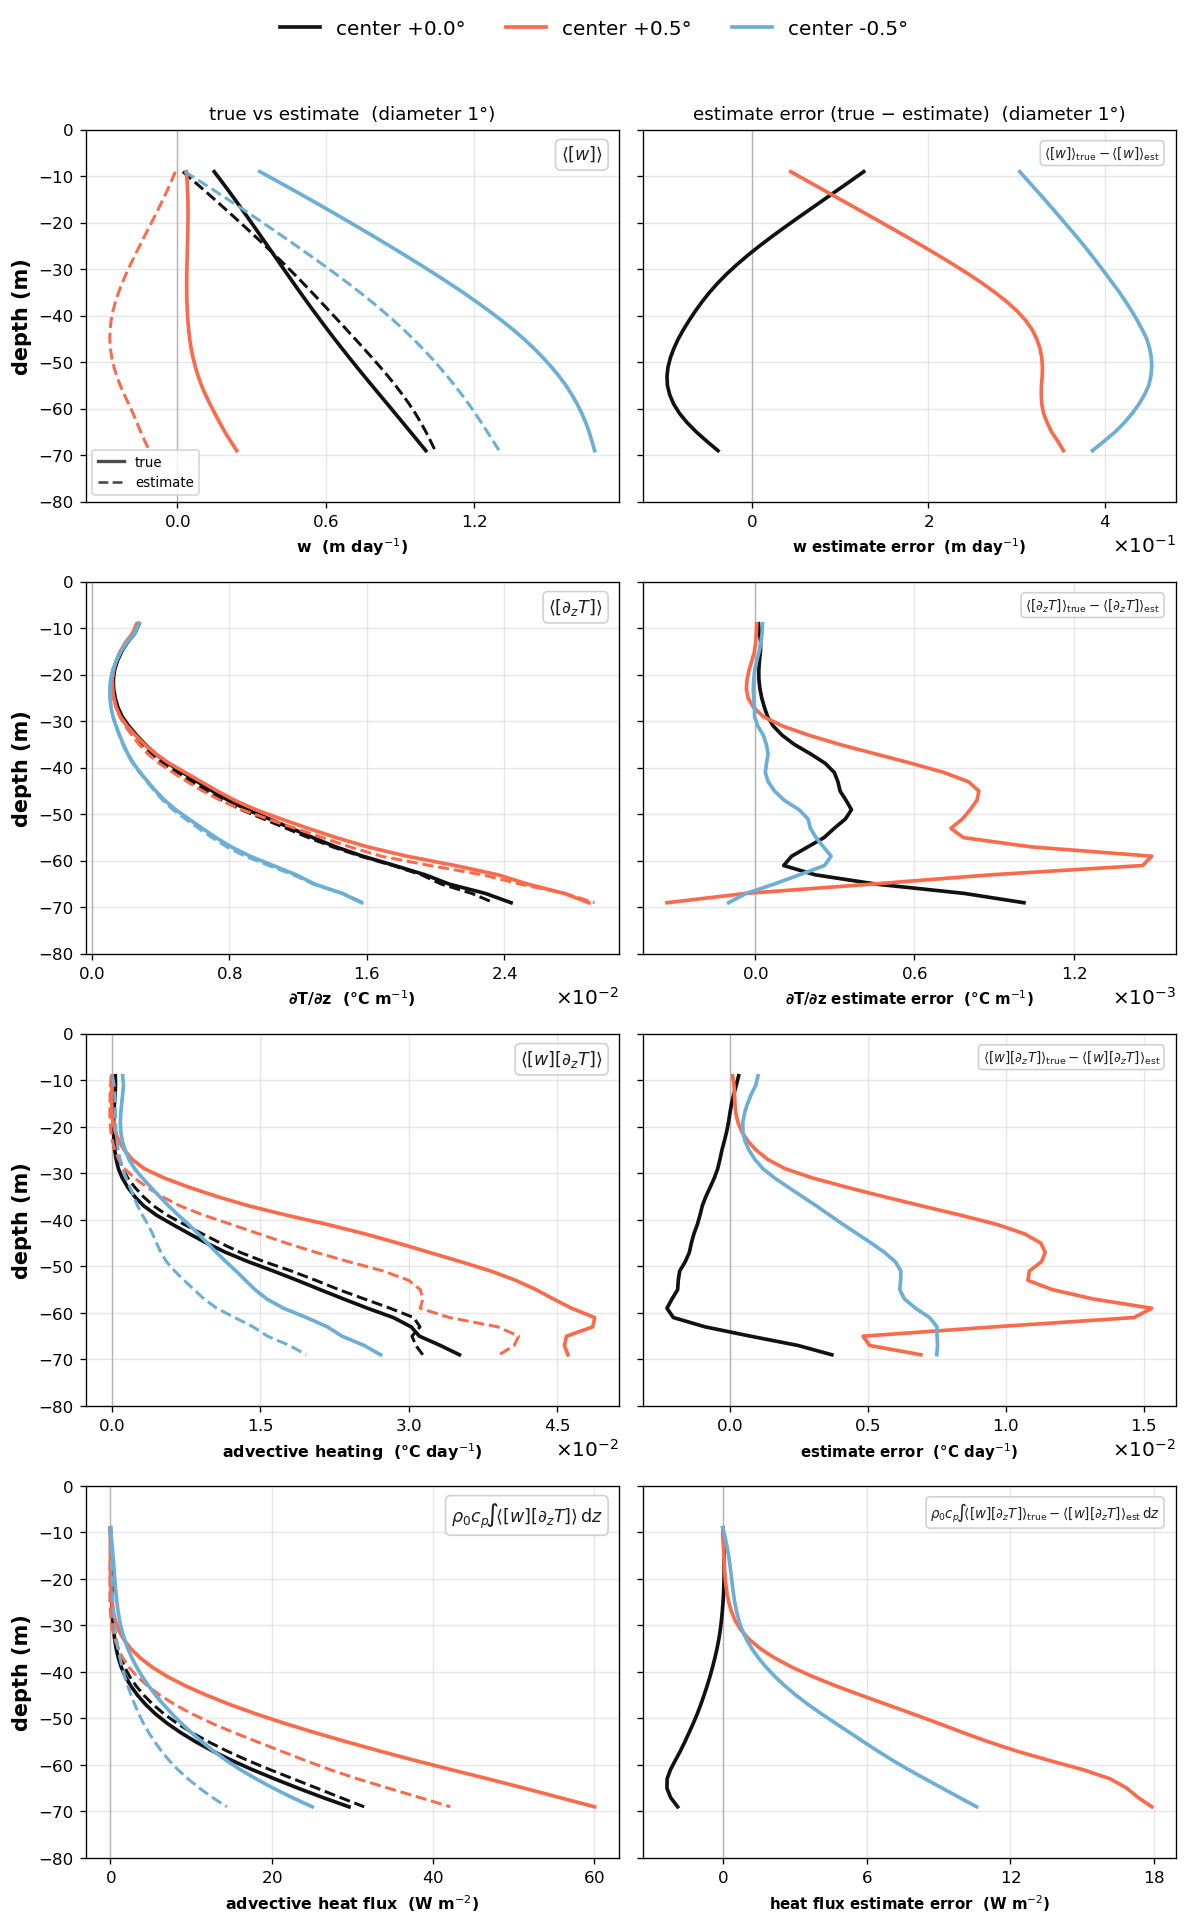

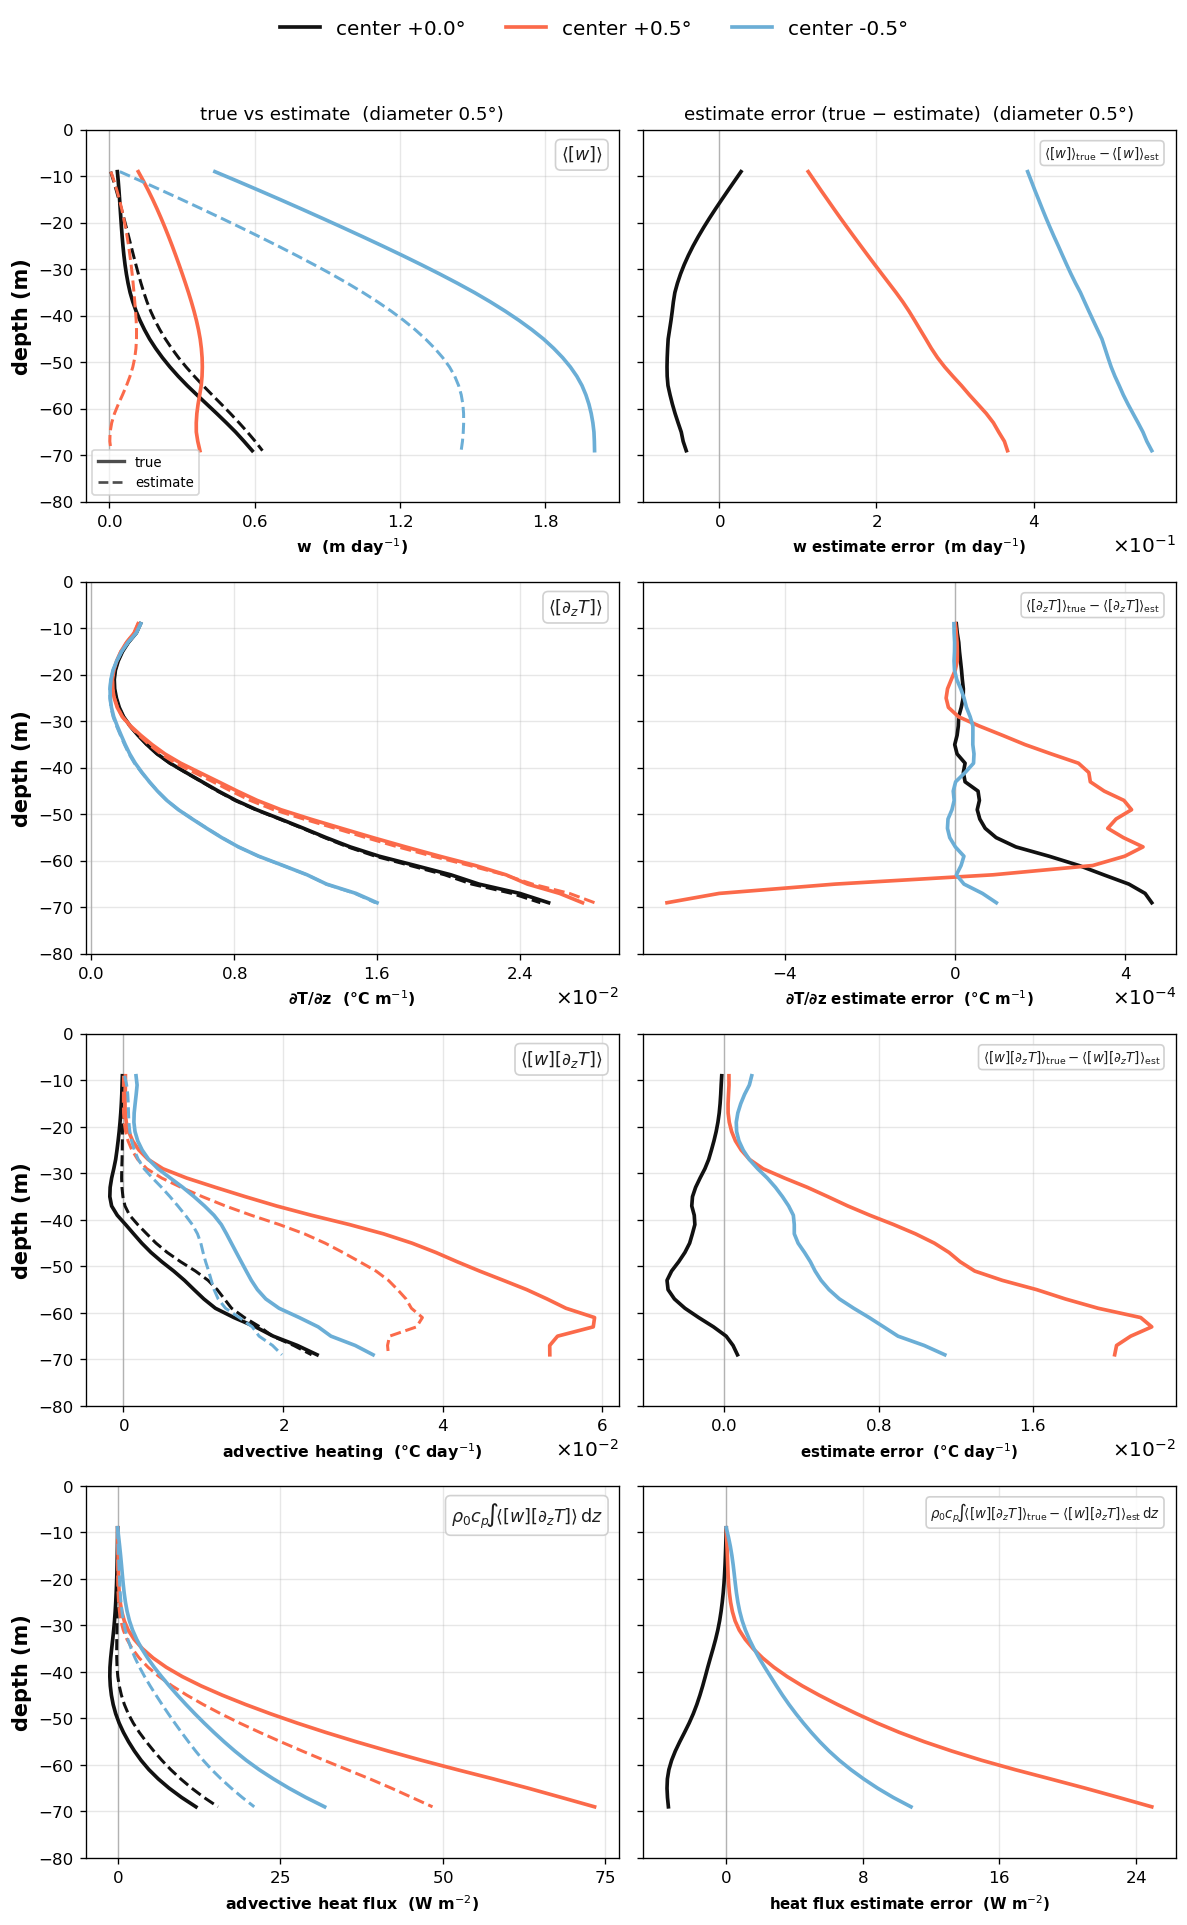

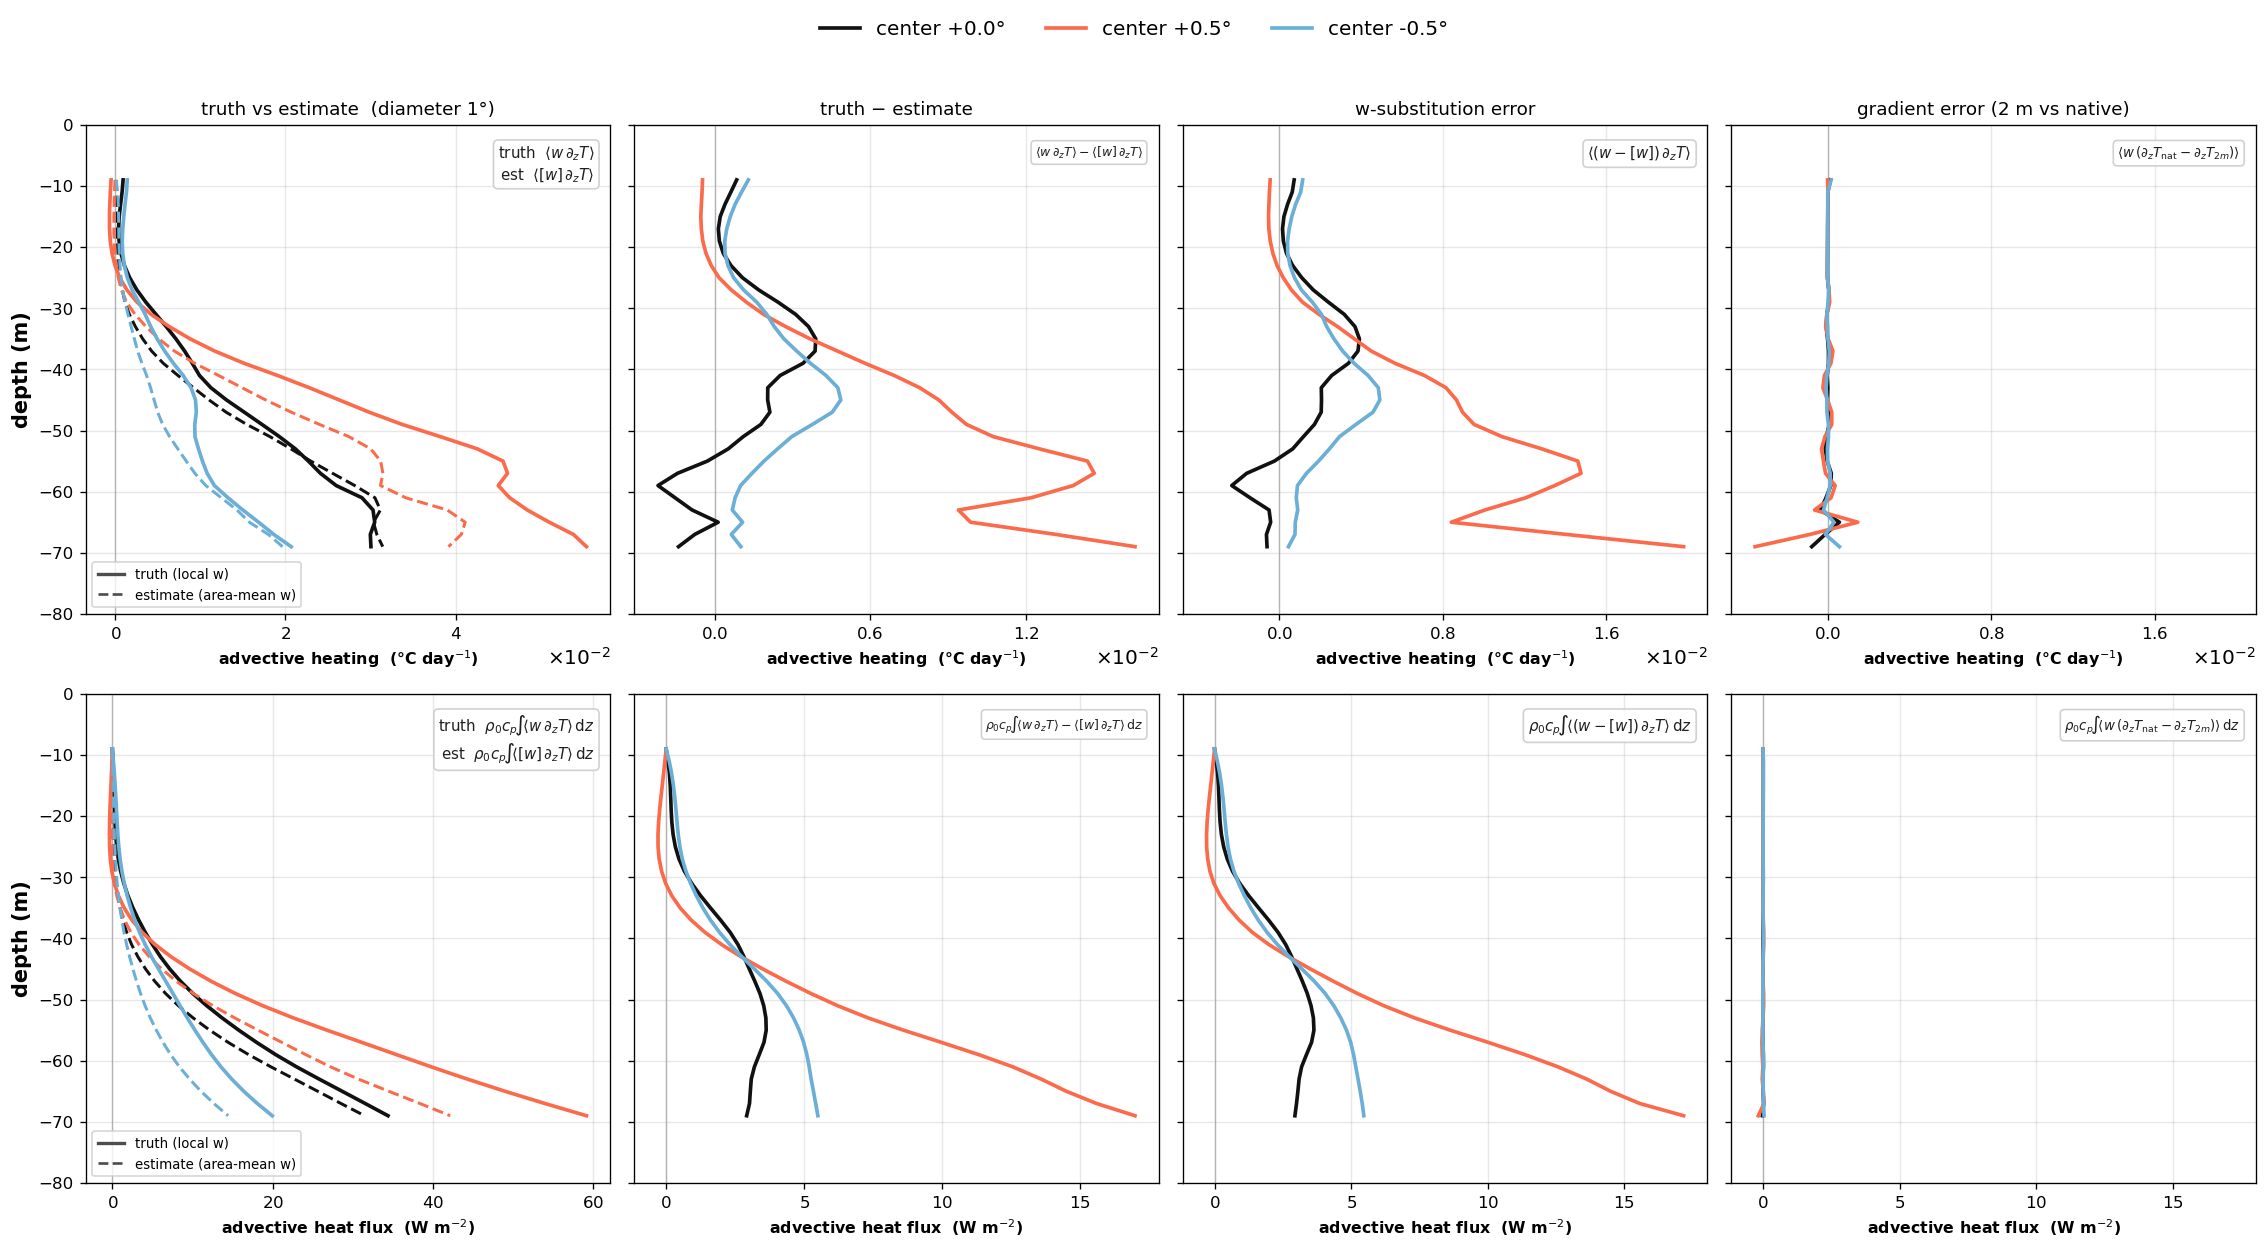

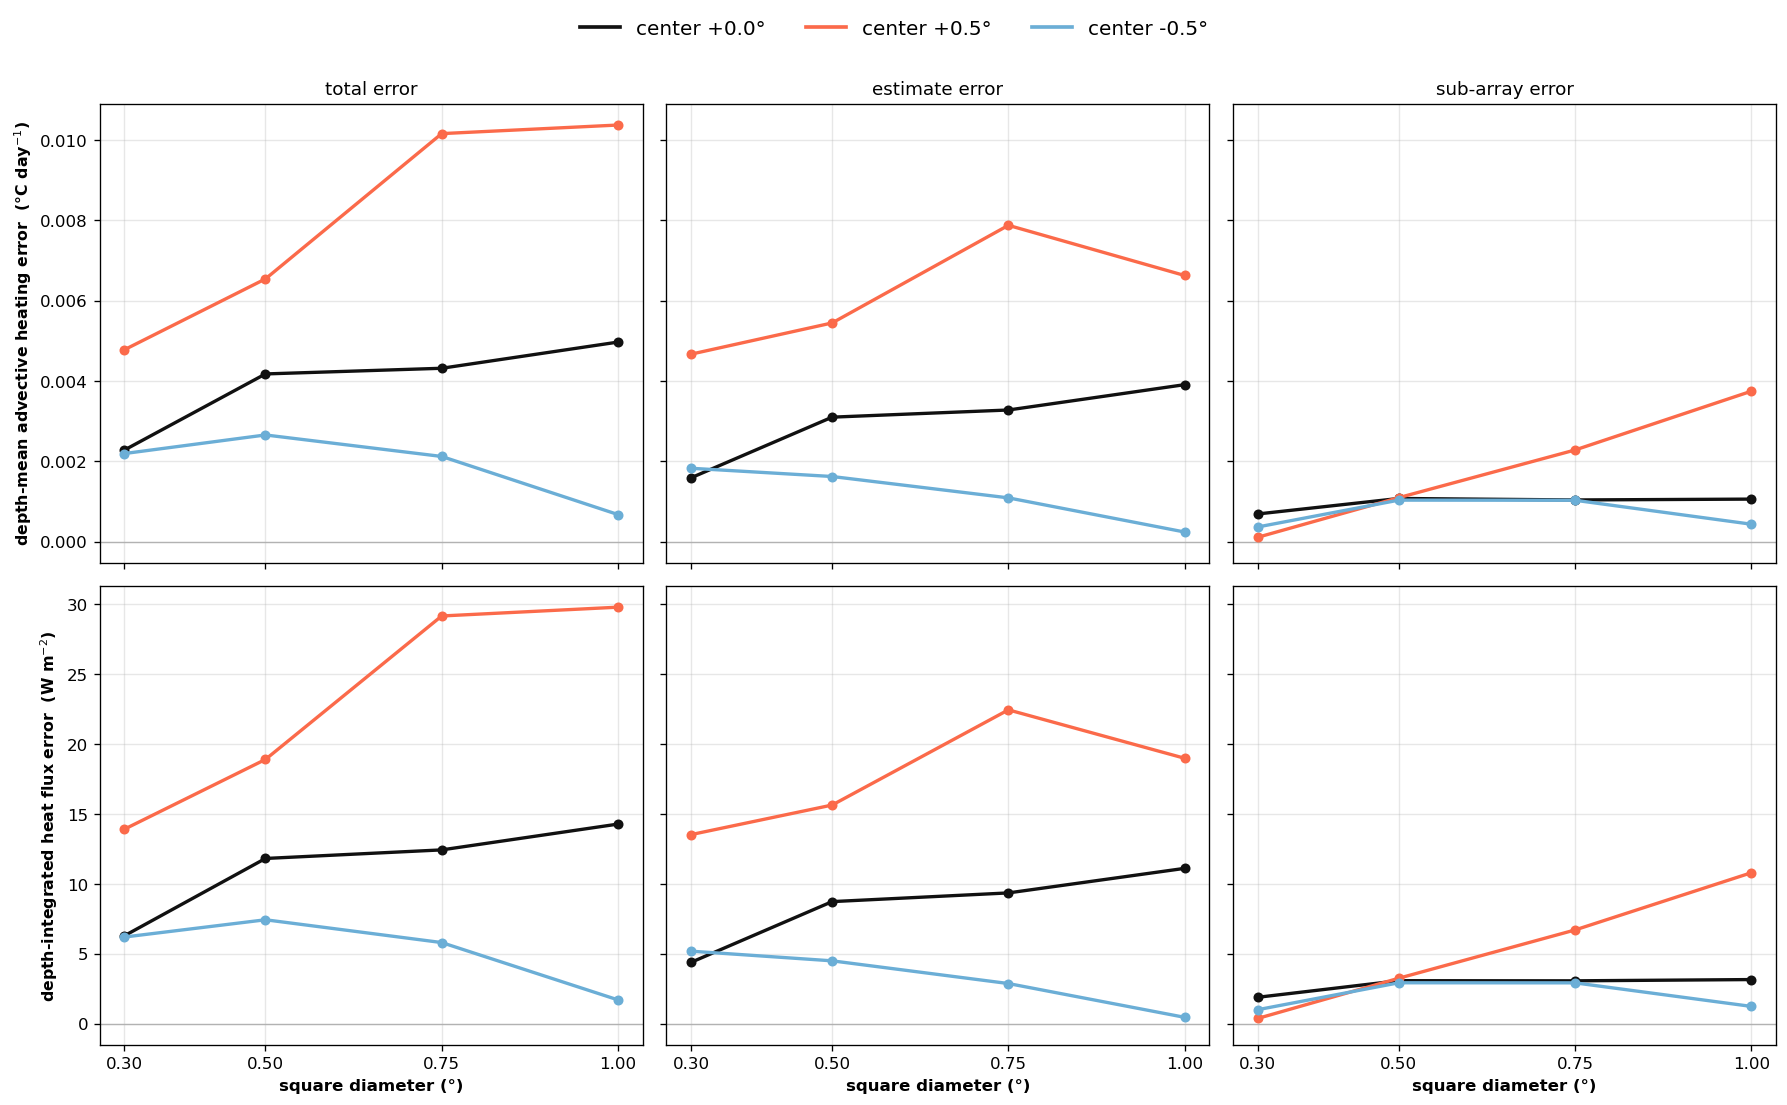

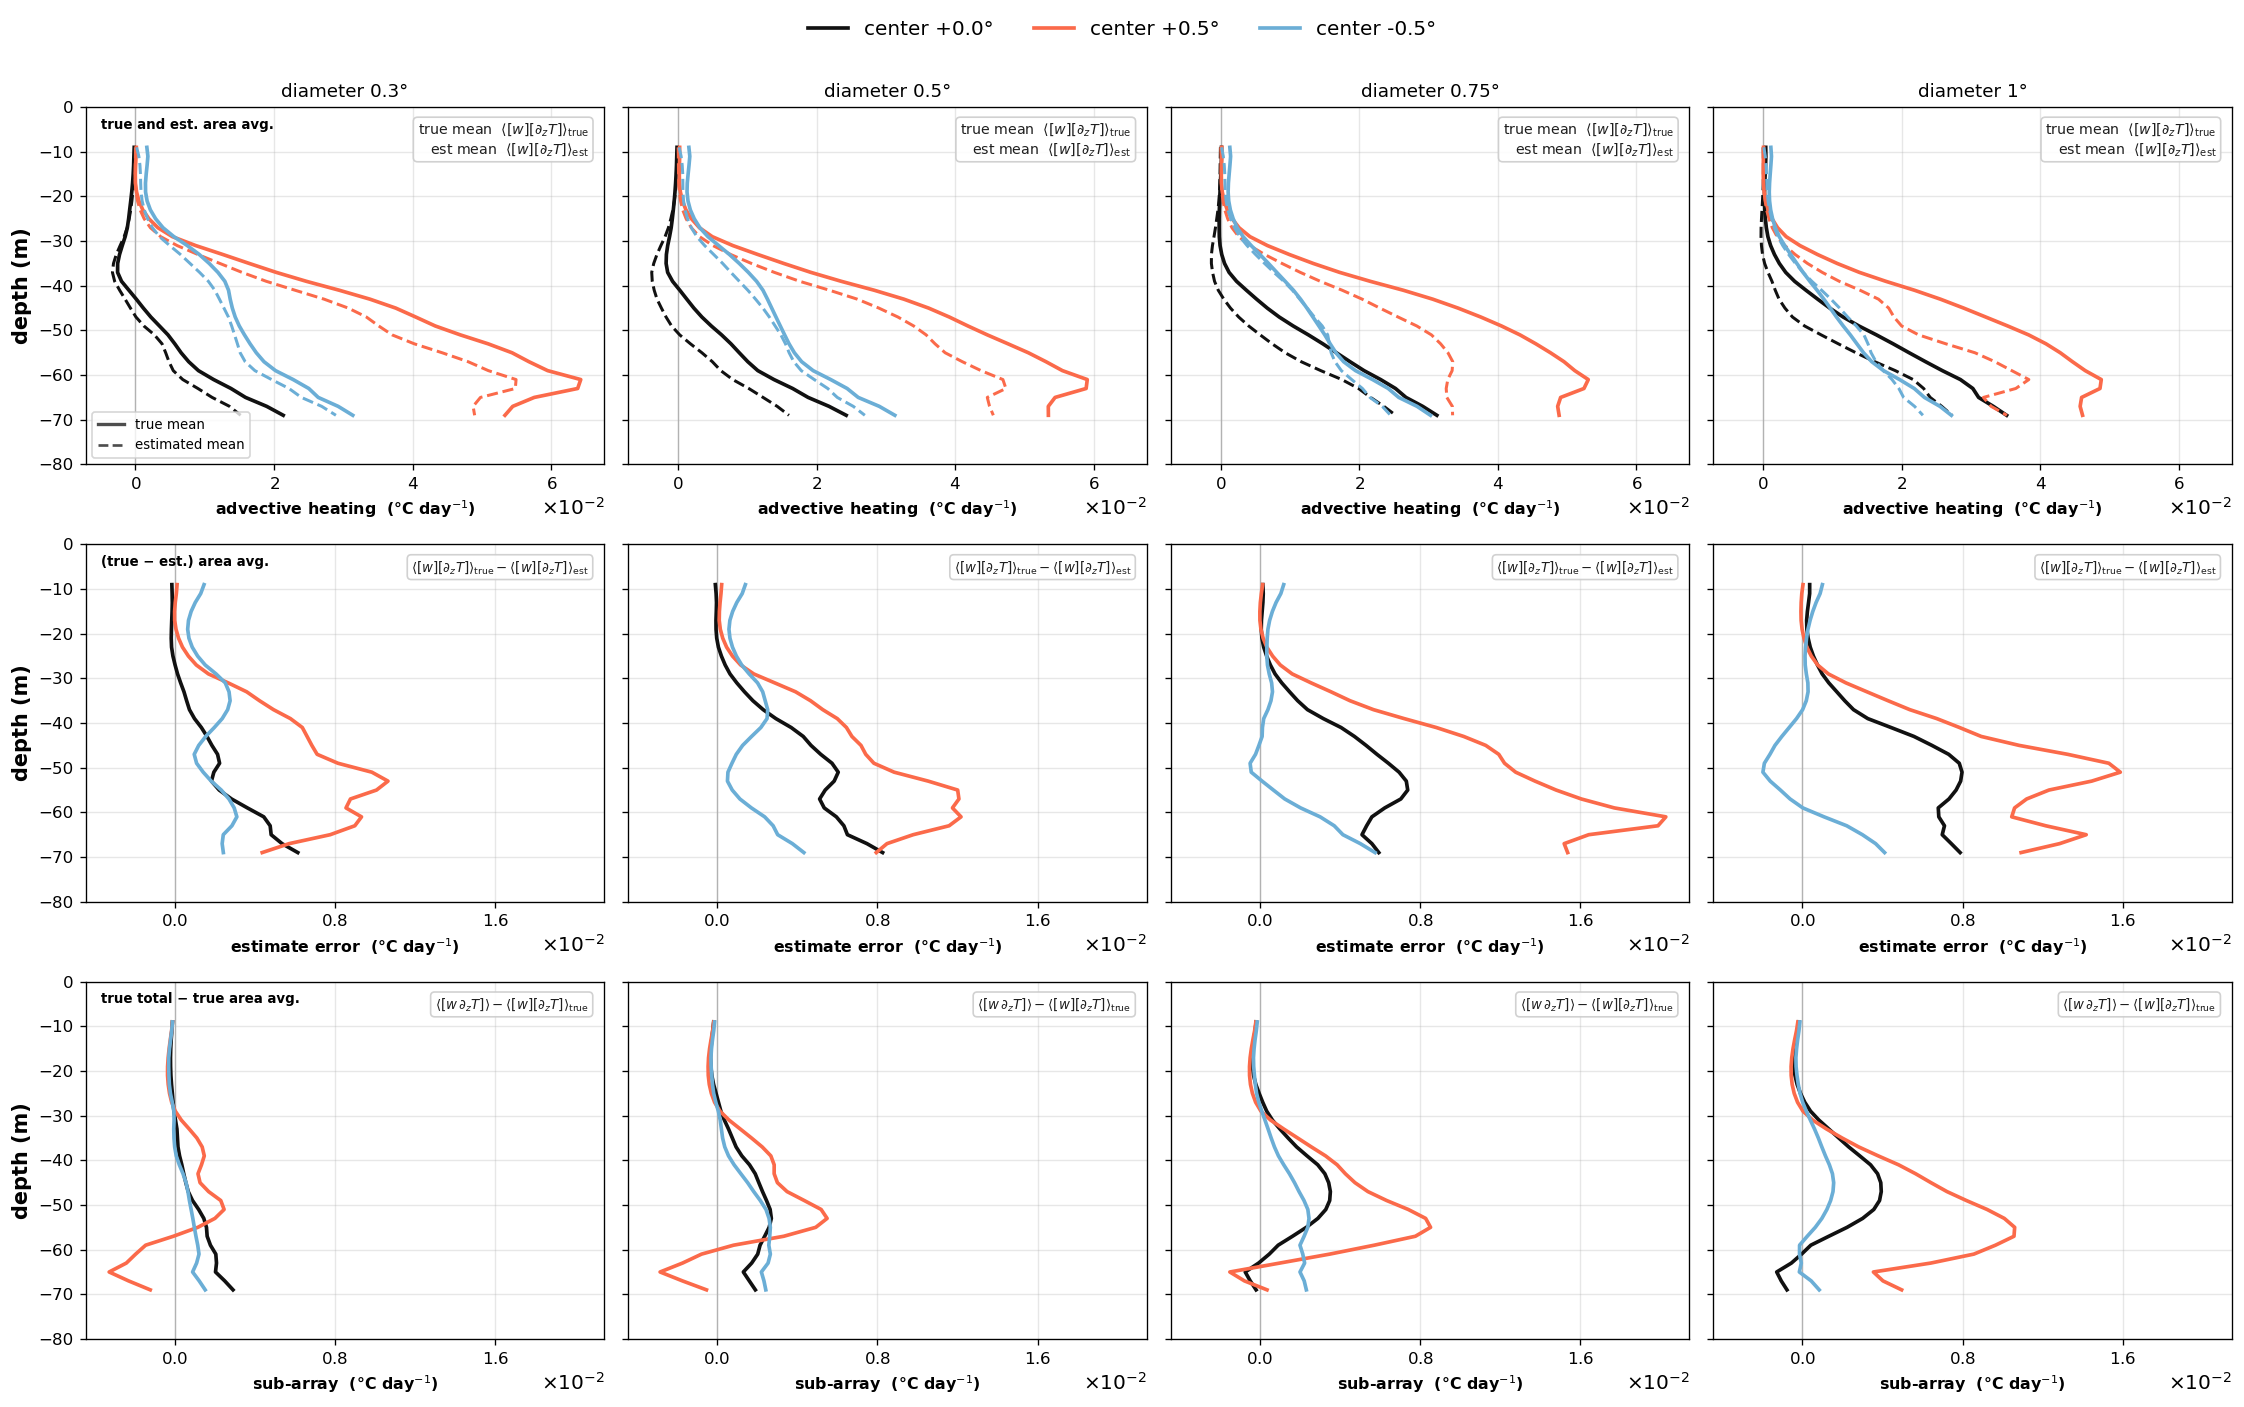

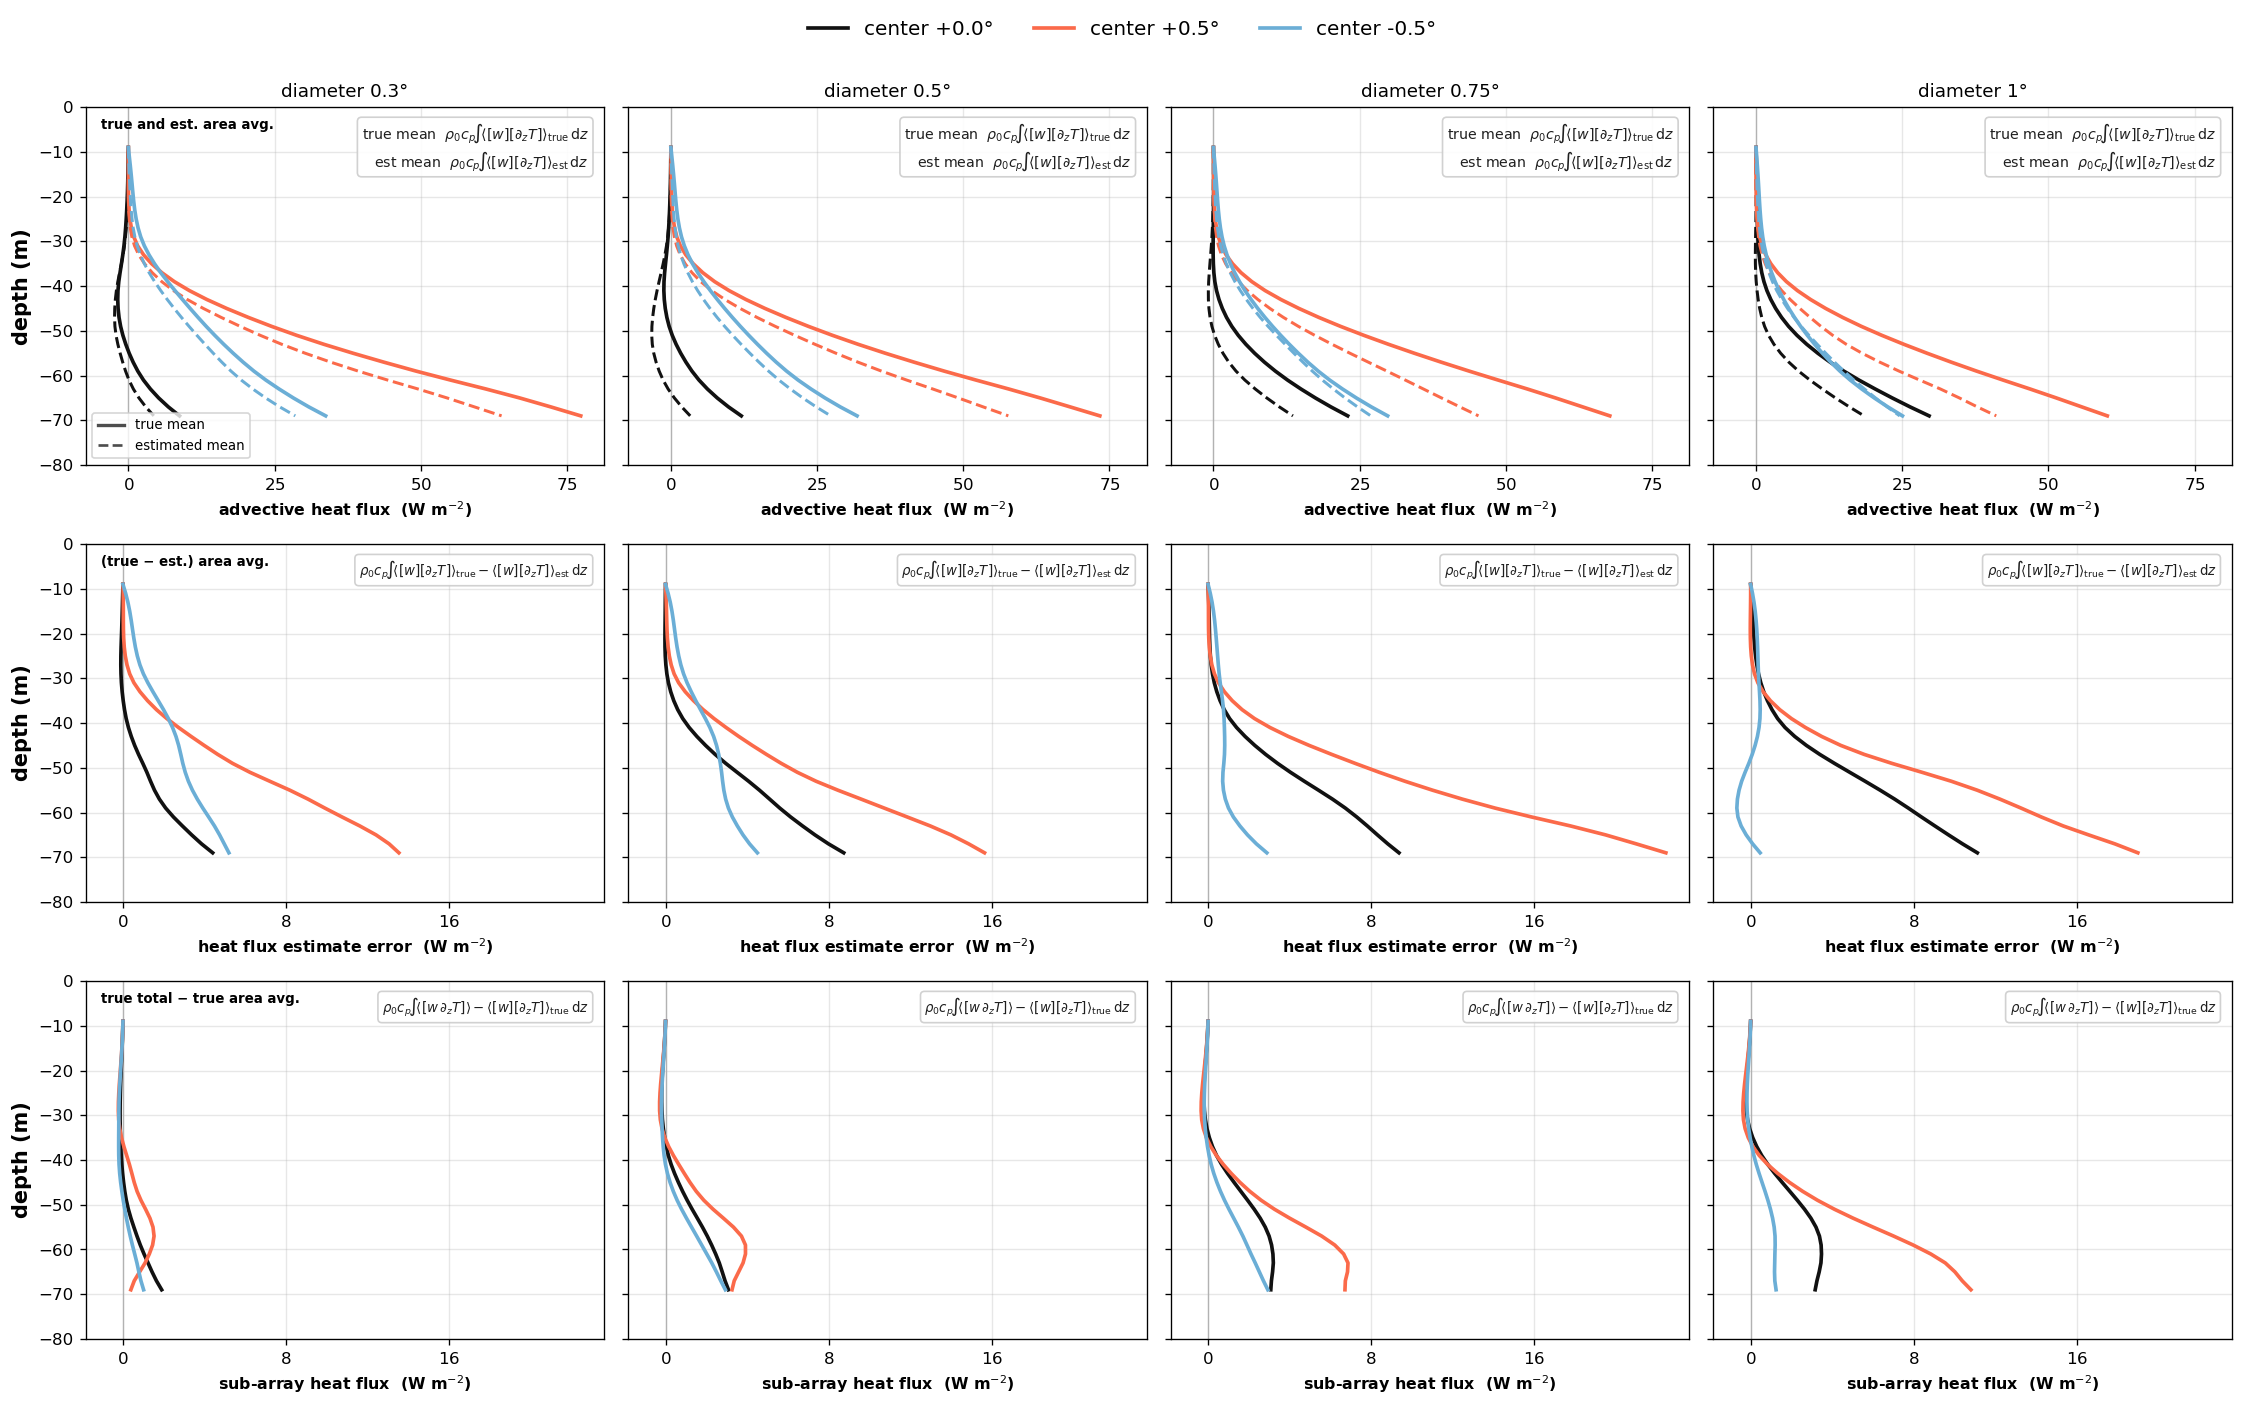

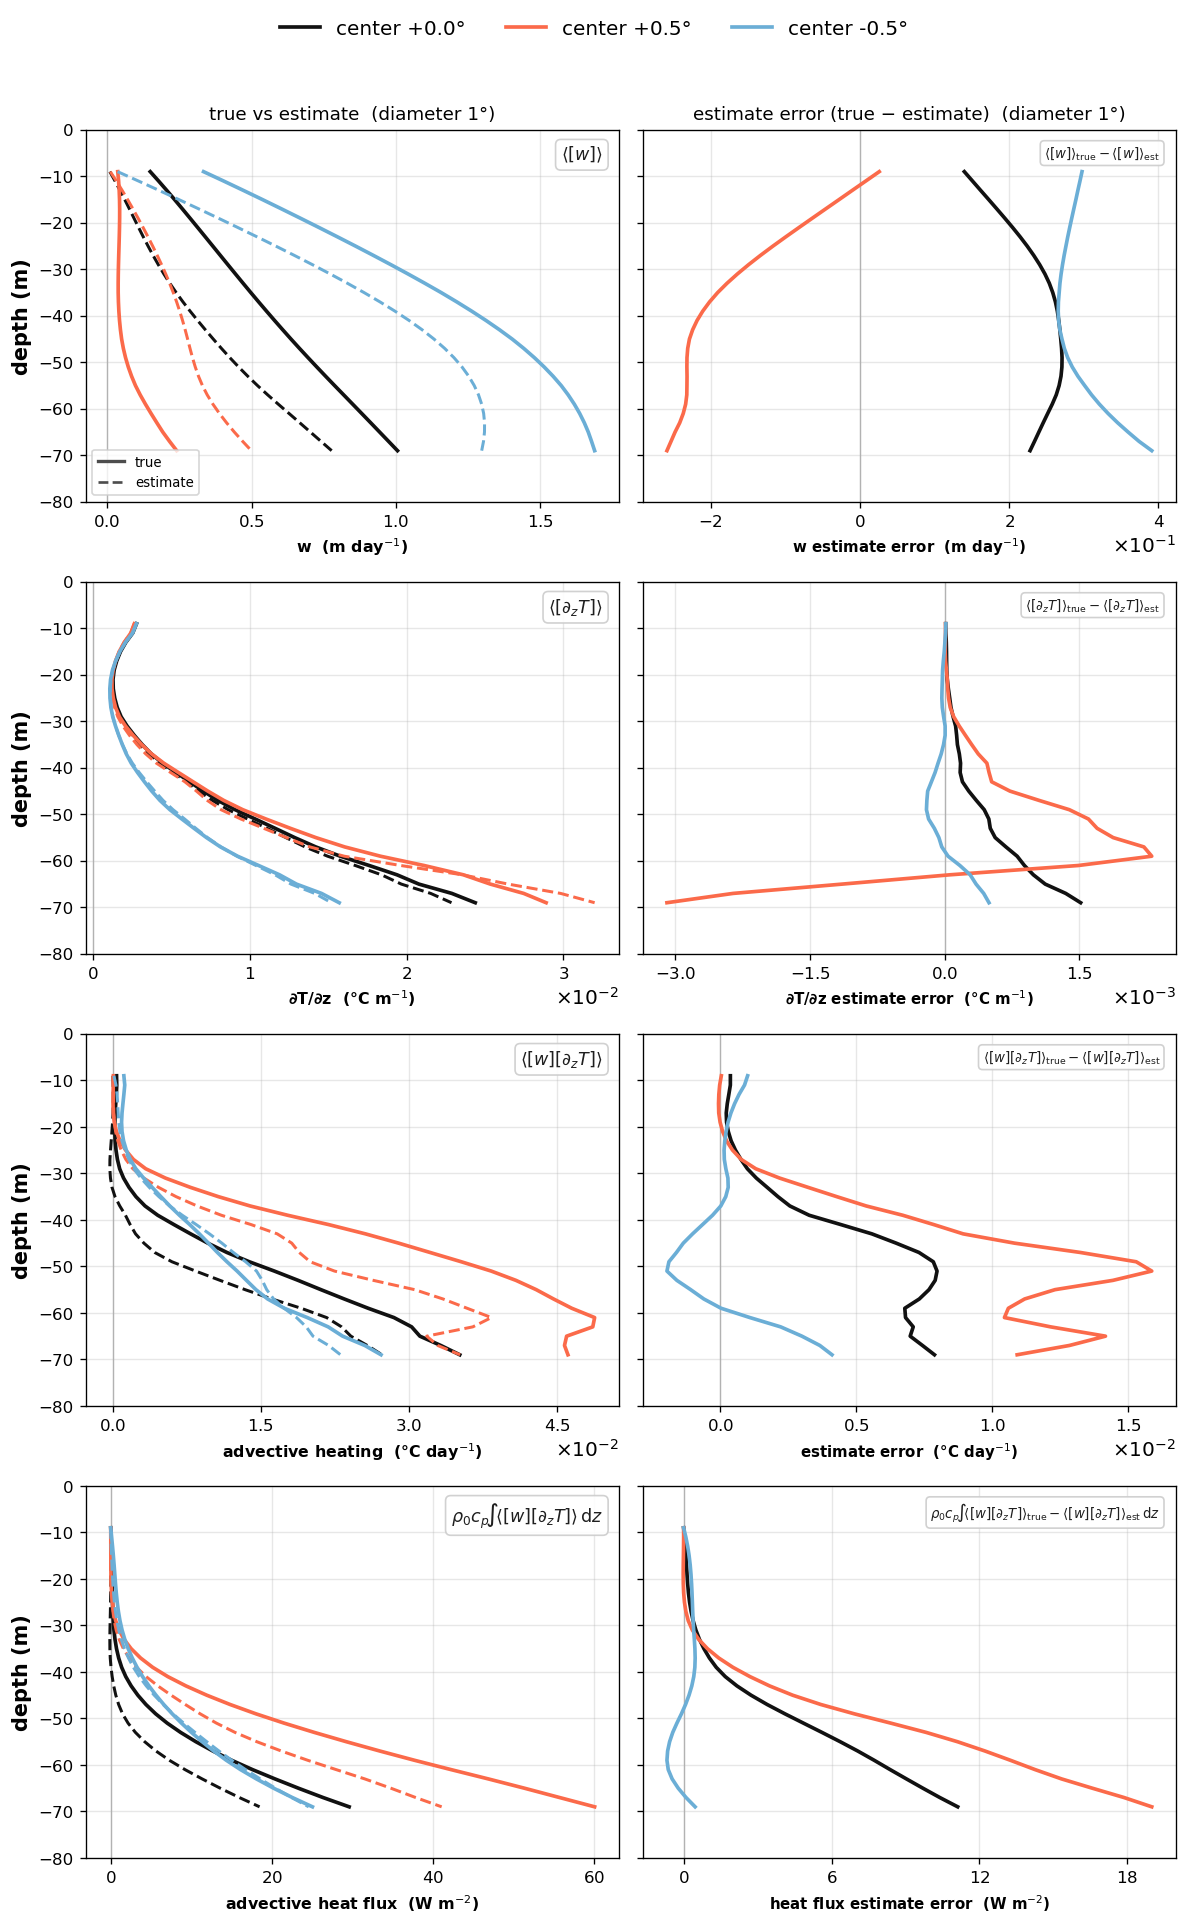

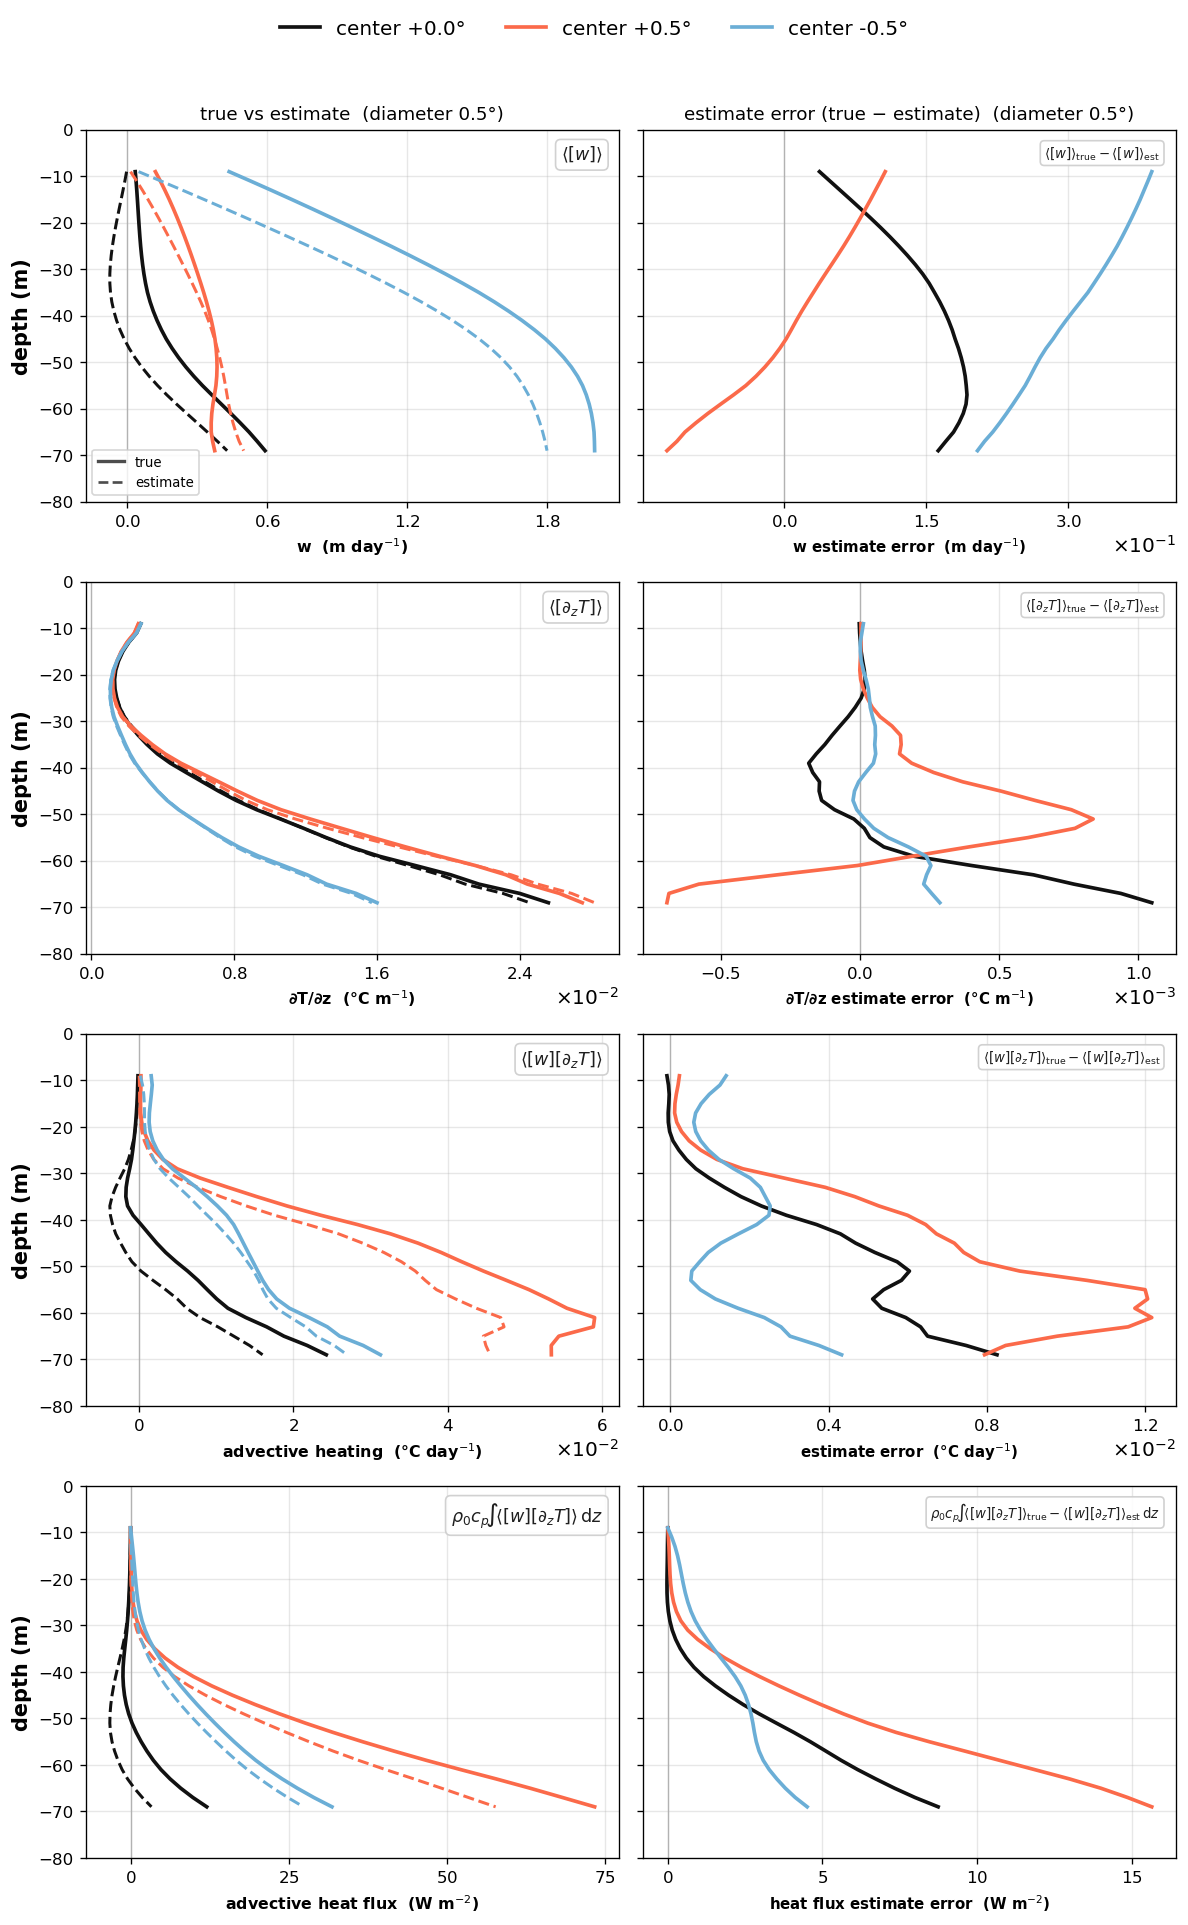

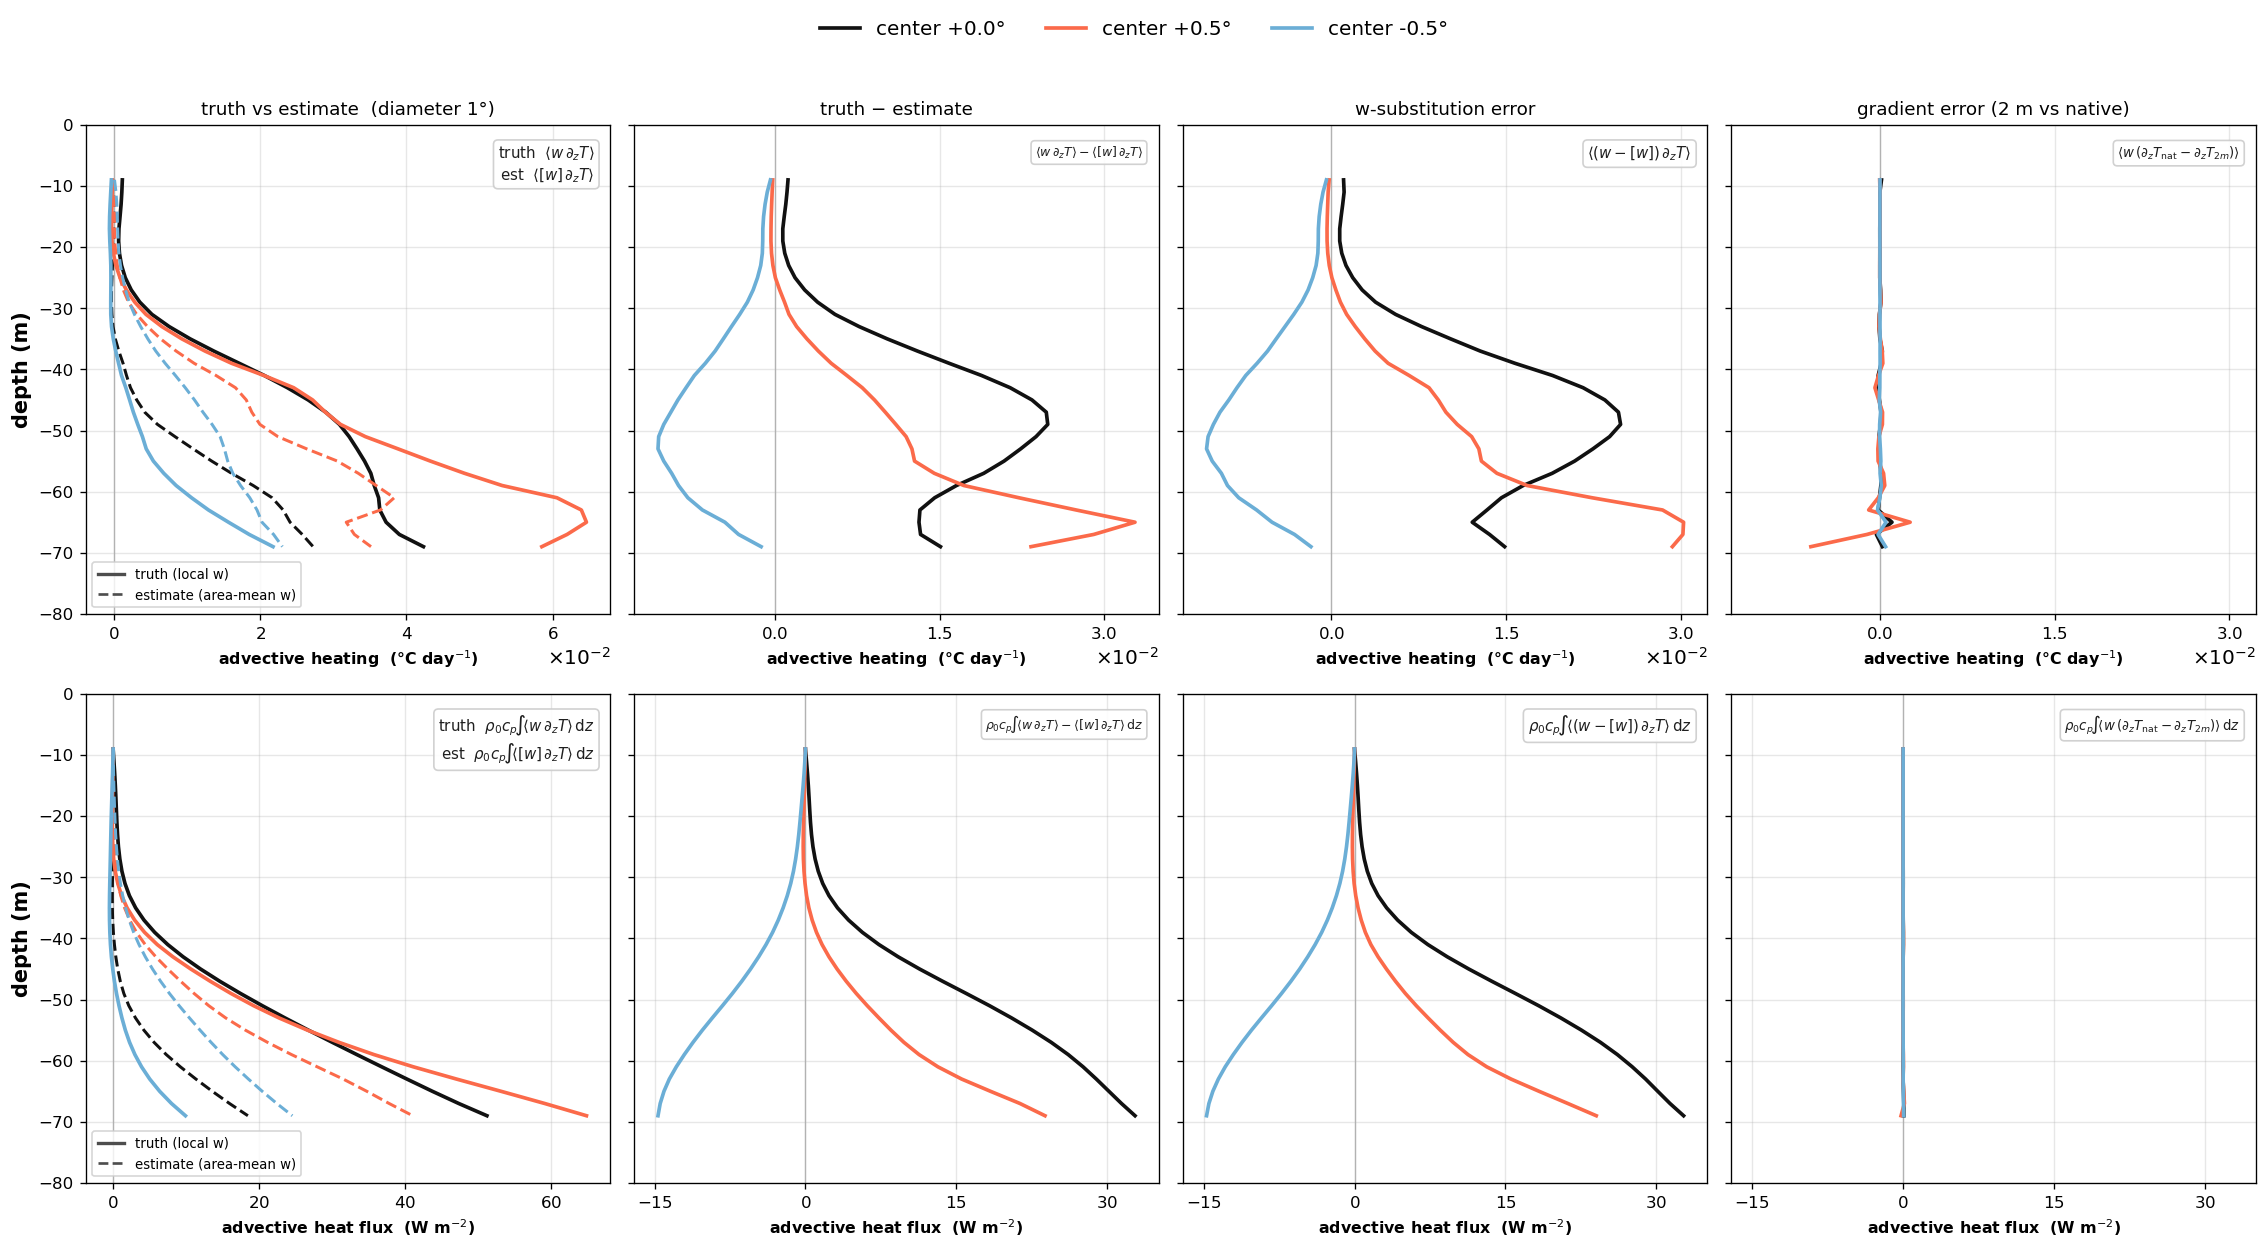

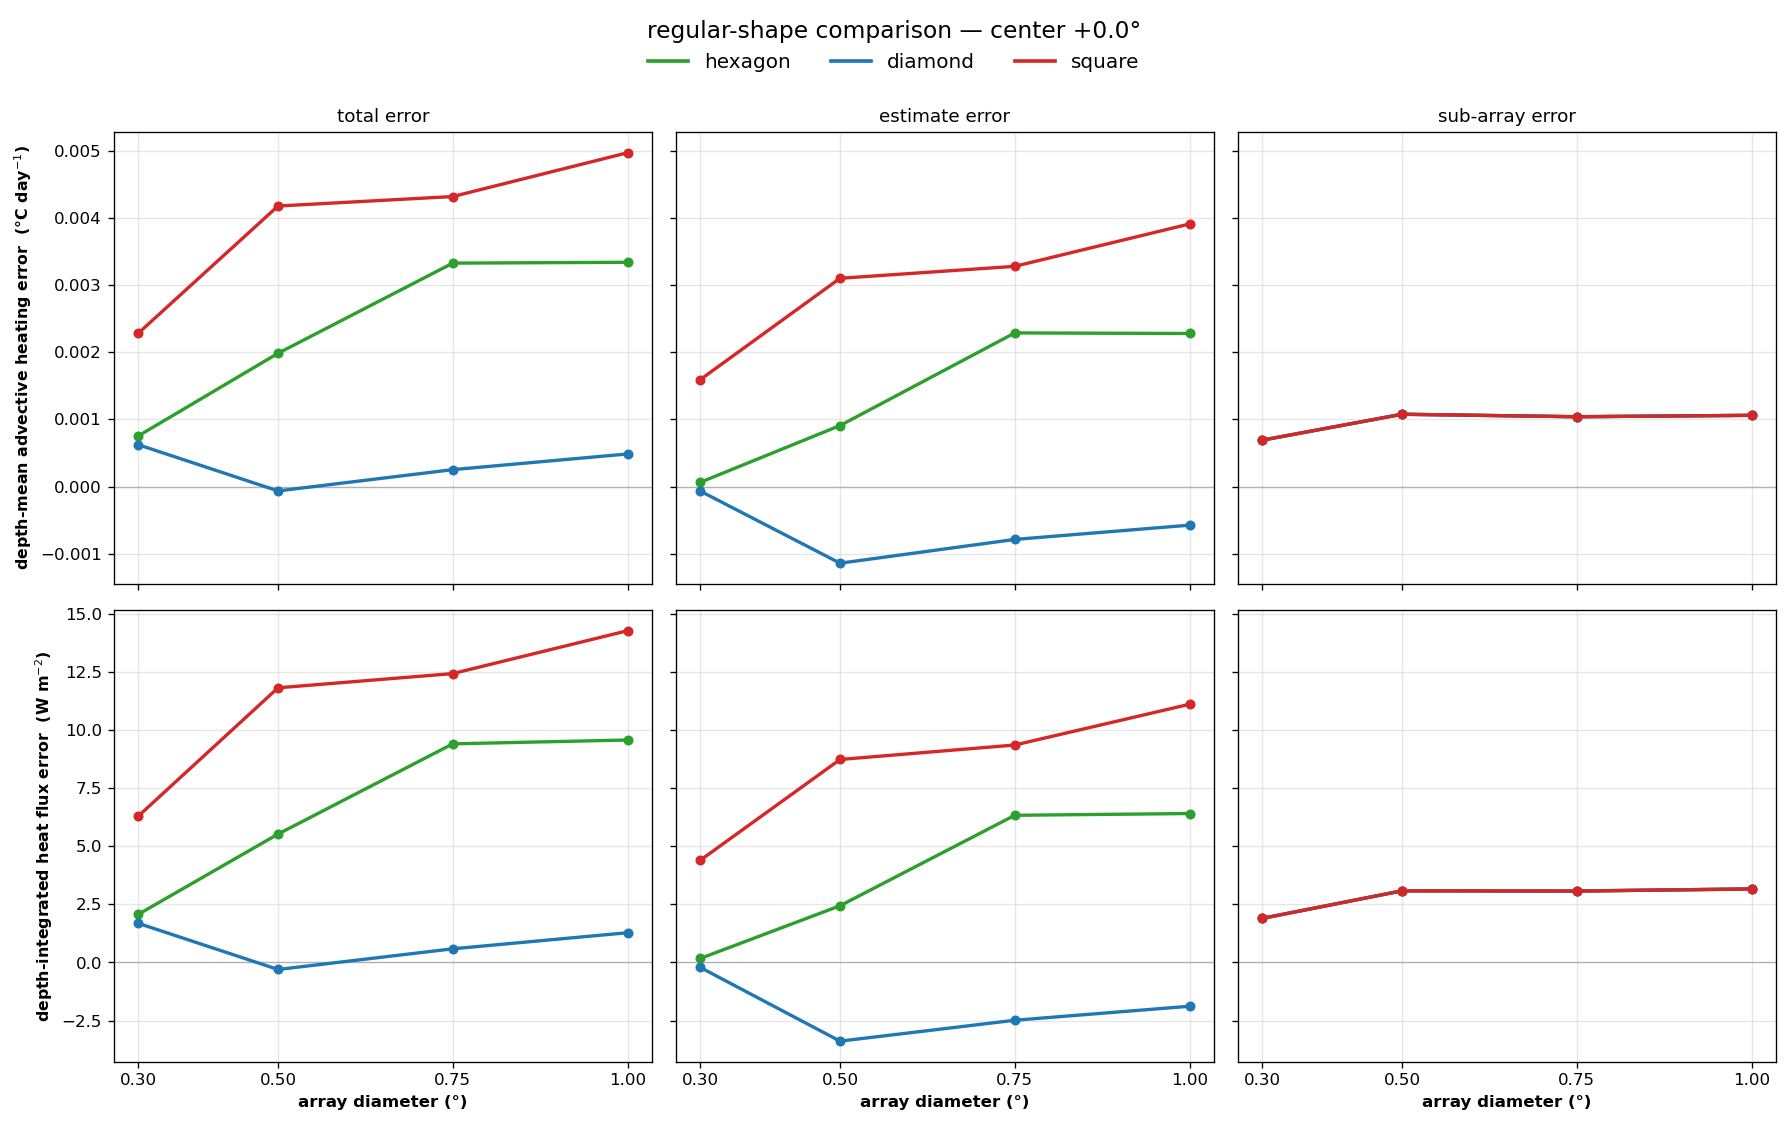

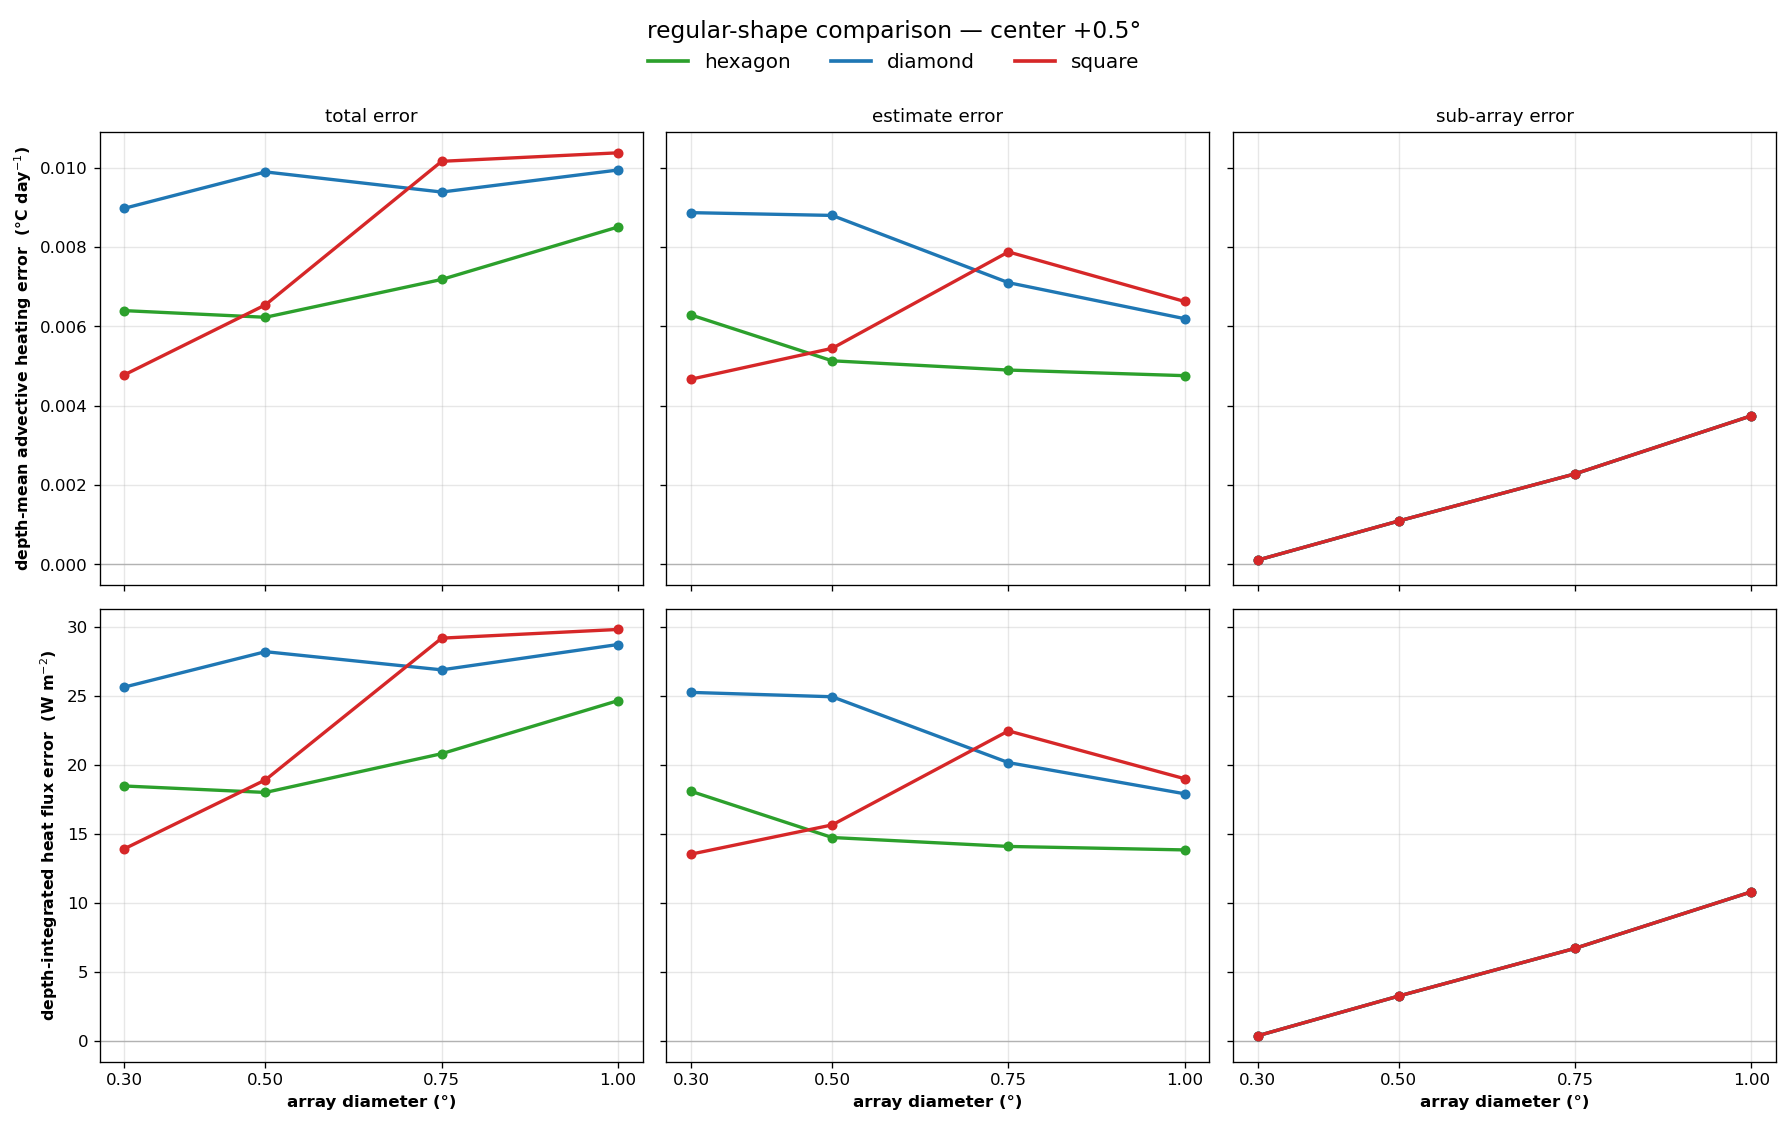

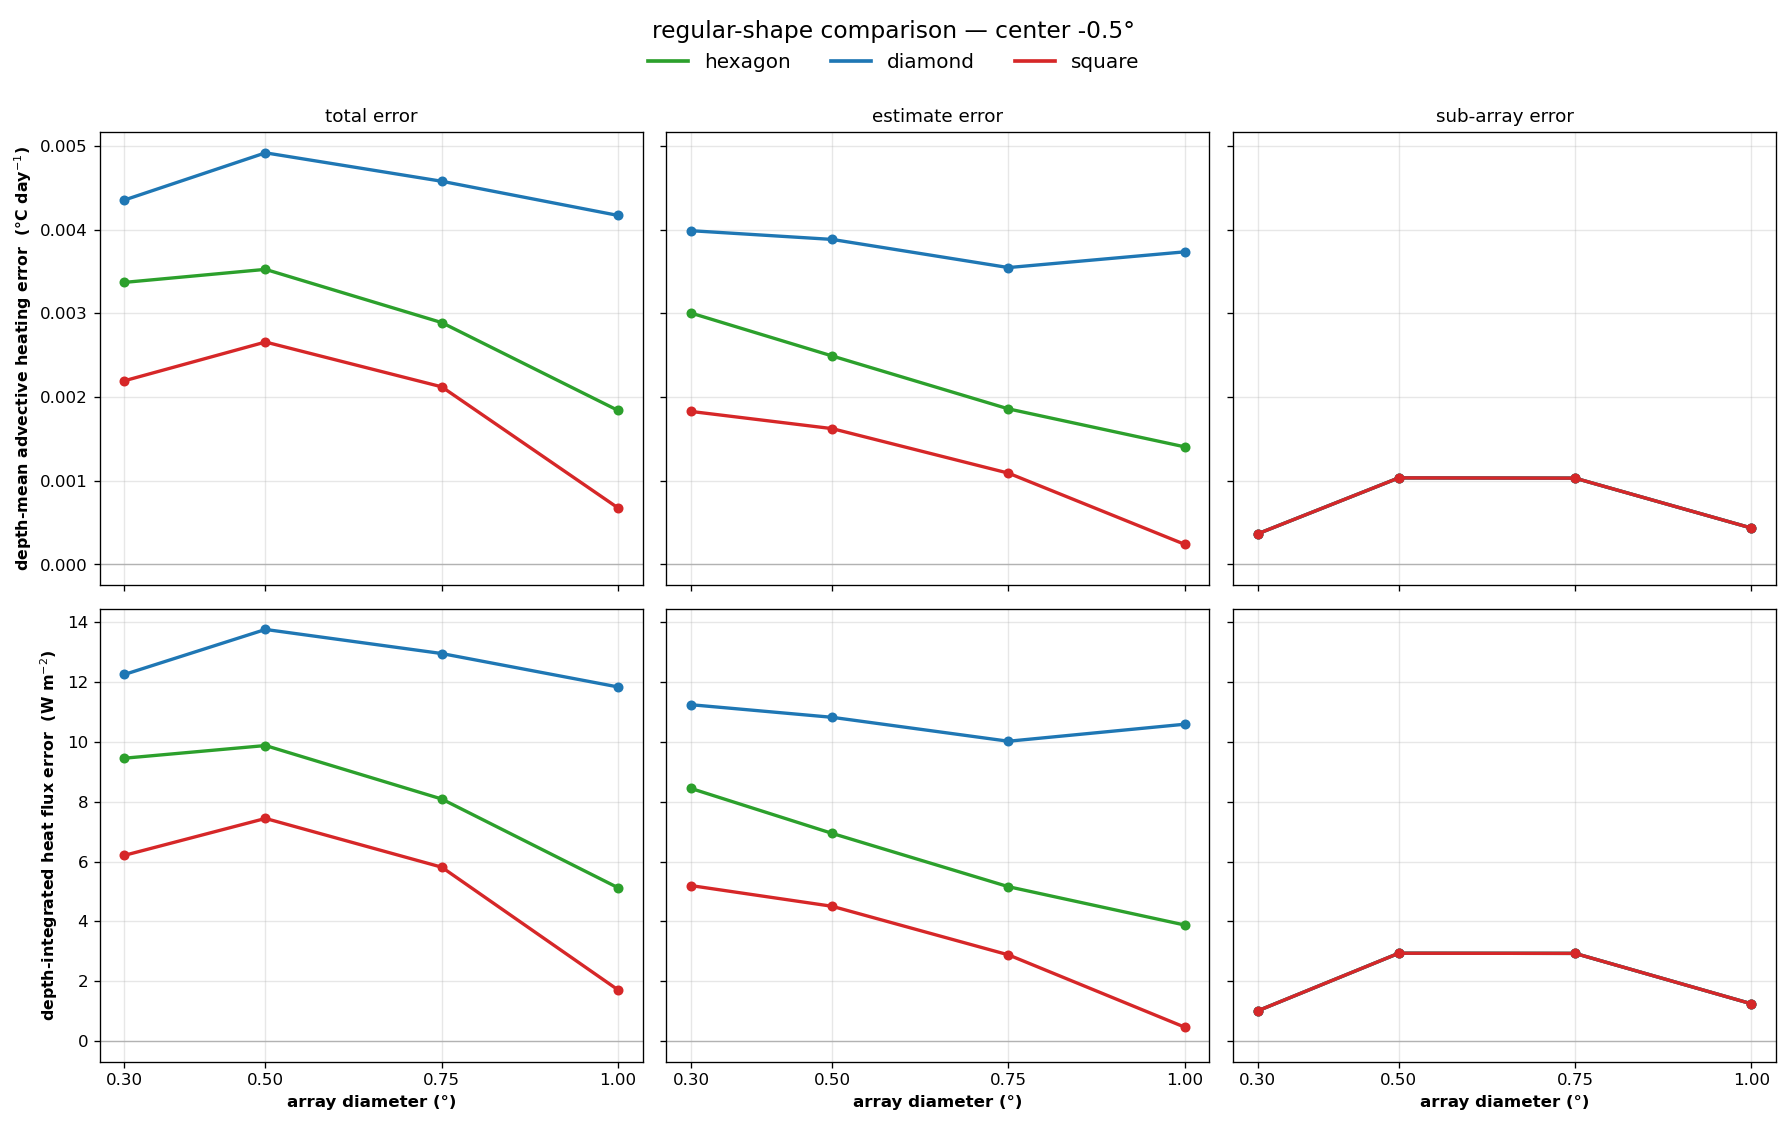

In [2]:
# ---- symmetric REGULAR-shape sweep (hexagon / diamond / square) -> sym_sweep/ ----
SYMDIR = os.path.join(HFIGDIR, "sym_sweep"); os.makedirs(SYMDIR, exist_ok=True)
def savesym(fig, name):
    fig.savefig(os.path.join(SYMDIR, name), bbox_inches="tight", dpi=150)
    return fig

for fam in hft.SYM_FAMILIES:                       # symhex, symdia, symsq
    # summary: area-average heating error vs diameter, one line per centre latitude
    savesym(hft.make_error_scaling_symhex(DATA, family=fam), f"error_scaling_{fam}.png")
    # structural components (columns = diameter, line per centre) + W/m2 duplicate
    sx = hft.symhex_components_xlims(DATA, family=fam)
    sxf = hft.symhex_components_xlims(DATA, family=fam, flux=True)
    savesym(hft.make_area_components_symhex(DATA, family=fam, xlims=sx), f"area_components_{fam}.png")
    savesym(hft.make_area_components_symhex(DATA, family=fam, flux=True, xlims=sxf), f"area_components_{fam}_flux.png")
    # reducible plane-fit [w]/[dT/dz] errors at 1.0 deg AND 0.5 deg; point stand-in at 1.0 deg
    savesym(hft.make_area_reducible_symhex(DATA, diam=1.0, family=fam), f"area_reducible_{fam}.png")
    savesym(hft.make_area_reducible_symhex(DATA, diam=0.5, family=fam), f"area_reducible_{fam}_d0.5.png")
    savesym(hft.make_point_flux_symhex(DATA, family=fam), f"point_flux_{fam}.png")

# shape comparison (hexagon vs diamond vs square), one figure per centre latitude
for c in hft.SYMHEX_CENTERS:
    savesym(hft.make_error_scaling_sym_shapes(DATA, center=c), f"shape_compare_error_scaling_c{c:+.1f}.png")